# PCA – Erdbeere Gesamt (Third Trial Set)

**Dataset:** `data/gold/Third_Trial_Set_PDM Erdbeere Gesamt 8-5-2026.csv`  
**Recipes:** 130 (Rez.-Nr.)  
**Ingredients:** 231 unique CAS numbers  
**Approach:** Principal Component Analysis on two representations:  
  1. **OAV fingerprint** (log-transformed Odour Activity Values) — 129 recipes × 130 CAS  
  2. **Odour-type profile** — 129 recipes × 20 odour types (summed OAV per type)  

Recipes are coloured by their **dominant odour type** (highest summed OAV).  
A biplot overlay shows the top ingredient contributors to each principal component.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import matplotlib.cm as cm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from pathlib import Path

# ── paths ──────────────────────────────────────────────────────────────────
BASE      = Path('..')
DATA_PATH = BASE / 'data/gold/Third_Trial_Set_PDM Erdbeere Gesamt 8-5-2026.csv'
OUT_DIR   = BASE / 'outputs'
OUT_DIR.mkdir(exist_ok=True)
IGNORE_PATH = BASE / 'data/gold/ignone_substances.csv'

print('Libraries loaded ✓')

Libraries loaded ✓


## 1 · Load & Clean Data

In [2]:
def parse_de_float(val):
    """Parse German-locale floats (comma as decimal separator, scientific notation)."""
    if pd.isna(val):
        return float('nan')
    s = str(val).strip().replace(',', '.')
    try:
        return float(s)
    except ValueError:
        return float('nan')

df = pd.read_csv(DATA_PATH, dtype=str)
df['Totalmenge'] = df['Totalmenge'].apply(parse_de_float)
df['Threshold']  = df['Threshold'].apply(parse_de_float)

print(f'Raw rows: {len(df):,}')
print(f'Unique recipes (Rez.-Nr.): {df["Rez.-Nr."].nunique()}')
print(f'Unique ingredients (Ident): {df["Ident"].nunique()}')
print(f'Unique CAS numbers: {df["CAS-Nr."].nunique()}')

# Collect all odour types
all_ot = pd.concat([
    df['Odour-Type 1'].dropna(),
    df['Odour-Type 2'].dropna(),
    df['Odour-Type 3'].dropna()
]).unique()
print(f'\nOdour types ({len(all_ot)}): {sorted(all_ot)}')

Raw rows: 3,369
Unique recipes (Rez.-Nr.): 130
Unique ingredients (Ident): 338
Unique CAS numbers: 231

Odour types (20): ['alcoholic', 'alliaceous', 'animalic', 'balsamic', 'citrus', 'dairy', 'ethereal', 'exotic', 'floral', 'fresh', 'fruity', 'green', 'herbal', 'minty', 'nutty', 'odorless', 'peppery', 'unpleasant', 'warm', 'woody']


In [3]:
# ── Apply ignore list ────────────────────────────────────────────────────────
if IGNORE_PATH.exists():
    ign             = pd.read_csv(IGNORE_PATH)
    ign_idents      = set(ign["Ident"].dropna().astype(str).str.strip())
    names_to_ignore = {str(n).lower().strip() for n in ign["Name"]}
    df.loc[df["Ident"].astype(str).str.strip().isin(ign_idents), "Totalmenge"] = 0.0
    df.loc[df["Name"].str.lower().str.strip().isin(names_to_ignore), "Totalmenge"] = 0.0
    print(f"Ignored idents: {len(ign_idents)} | Ignored names: {len(names_to_ignore)}")
else:
    print('No ignore list found — all ingredients included.')


Ignored idents: 10 | Ignored names: 10


In [4]:
# ── OAV calculation ─────────────────────────────────────────────────────────
# Threshold is a property of the CAS number (constant across recipes)
cas_thresh = df.groupby('CAS-Nr.')['Threshold'].first().dropna()
print(f'CAS numbers with threshold data: {len(cas_thresh)}')

df_t = df[df['CAS-Nr.'].isin(cas_thresh.index)].copy()
df_t['thresh'] = df_t['CAS-Nr.'].map(cas_thresh)
df_t['OAV']    = df_t['Totalmenge'] / df_t['thresh']
df_t['OAV']    = df_t['OAV'].replace([np.inf, -np.inf], np.nan)
df_t = df_t.dropna(subset=['OAV'])

print(f'Rows with valid OAV: {len(df_t):,}')
print(f'Recipes with OAV data: {df_t["Rez.-Nr."].nunique()}')
print(f'\nOAV distribution (log10 scale):')
logOAV = np.log10(df_t['OAV'].clip(lower=1e-10))
print(logOAV.describe().round(2))

CAS numbers with threshold data: 131
Rows with valid OAV: 2,903
Recipes with OAV data: 129

OAV distribution (log10 scale):
count    2903.00
mean       -2.81
std         1.39
min       -10.00
25%        -3.70
50%        -2.70
75%        -1.74
max         0.53
Name: OAV, dtype: float64


In [5]:
# ── Build Recipe × CAS OAV matrix ───────────────────────────────────────────
pivot_oav = df_t.pivot_table(
    index='Rez.-Nr.', columns='CAS-Nr.',
    values='OAV', aggfunc='sum', fill_value=0
)
print(f'Recipe × CAS matrix: {pivot_oav.shape}')
print(f'Avg CAS per recipe: {(pivot_oav > 0).sum(axis=1).mean():.1f}')

# log1p transform: compress the many-orders-of-magnitude OAV range
X_oav = np.log1p(pivot_oav.values.clip(min=0))

Recipe × CAS matrix: (129, 130)
Avg CAS per recipe: 22.5


In [6]:
# ── Build Recipe × OdourType OAV profile ────────────────────────────────────
rows = []
for _, row in df_t.iterrows():
    for col in ['Odour-Type 1', 'Odour-Type 2', 'Odour-Type 3']:
        ot = row[col]
        if pd.notna(ot):
            rows.append({'Recipe': row['Rez.-Nr.'], 'OdourType': ot, 'OAV': row['OAV']})

ot_df = pd.DataFrame(rows)
pivot_ot = ot_df.groupby(['Recipe','OdourType'])['OAV'].sum().unstack(fill_value=0)
print(f'Recipe × OdourType matrix: {pivot_ot.shape}')
print(f'Odour types: {pivot_ot.columns.tolist()}')

# log1p transform
X_ot = np.log1p(pivot_ot.values.clip(min=0))

# Dominant odour type per recipe (for colouring)
dom_ot_series = pivot_ot.idxmax(axis=1)
print(f'\nDominant odour type distribution:')
print(dom_ot_series.value_counts())

Recipe × OdourType matrix: (129, 11)
Odour types: ['balsamic', 'dairy', 'exotic', 'floral', 'fresh', 'fruity', 'green', 'odorless', 'unpleasant', 'warm', 'woody']

Dominant odour type distribution:
fruity    95
fresh     20
warm      13
floral     1
Name: count, dtype: int64


## 2 · PCA on OAV Fingerprint (recipes × CAS)

In [7]:
# ── Fit PCA ─────────────────────────────────────────────────────────────────
scaler_oav = StandardScaler()
X_oav_scaled = scaler_oav.fit_transform(X_oav)

n_components = min(10, X_oav.shape[1], X_oav.shape[0])
pca_oav = PCA(n_components=n_components, random_state=42)
scores_oav = pca_oav.fit_transform(X_oav_scaled)

ev = pca_oav.explained_variance_ratio_ * 100
print('Explained variance per component:')
for i, v in enumerate(ev):
    print(f'  PC{i+1}: {v:.1f}%  (cumulative: {ev[:i+1].sum():.1f}%)')

Explained variance per component:
  PC1: 7.1%  (cumulative: 7.1%)
  PC2: 5.3%  (cumulative: 12.5%)
  PC3: 4.6%  (cumulative: 17.1%)
  PC4: 4.0%  (cumulative: 21.1%)
  PC5: 3.9%  (cumulative: 25.1%)
  PC6: 3.7%  (cumulative: 28.8%)
  PC7: 3.4%  (cumulative: 32.2%)
  PC8: 3.3%  (cumulative: 35.5%)
  PC9: 3.3%  (cumulative: 38.8%)
  PC10: 3.2%  (cumulative: 42.0%)


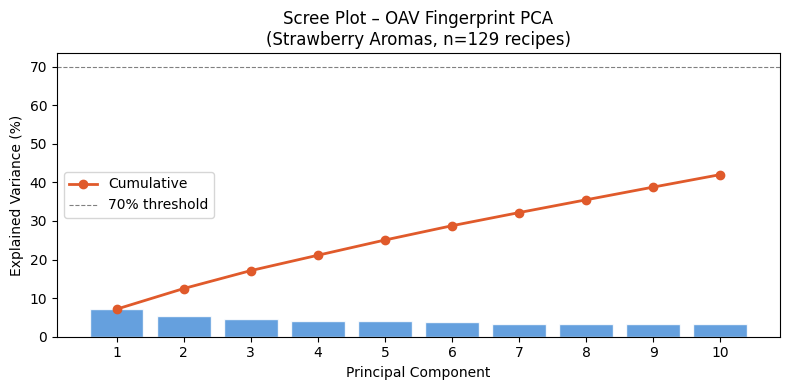

Saved: pca_v1_scree_oav.png


In [8]:
# ── Scree plot ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, len(ev)+1), ev, color='#4A90D9', alpha=0.85, edgecolor='white')
ax.plot(range(1, len(ev)+1), np.cumsum(ev), 'o-', color='#E05A2B', lw=2, label='Cumulative')
ax.axhline(70, ls='--', color='grey', lw=0.8, label='70% threshold')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance (%)')
ax.set_title('Scree Plot – OAV Fingerprint PCA\n(Strawberry Aromas, n=129 recipes)')
ax.set_xticks(range(1, len(ev)+1))
ax.legend()
plt.tight_layout()
fig.savefig(OUT_DIR / 'pca_v1_scree_oav.png', dpi=150)
plt.show()
print('Saved: pca_v1_scree_oav.png')

In [9]:
# ── Colour palette for odour types ──────────────────────────────────────────
ODOUR_PALETTE = {
    'fruity':     '#E05A2B',
    'floral':     '#D44F9A',
    'green':      '#4CAF50',
    'fresh':      '#29B6F6',
    'citrus':     '#FFA726',
    'dairy':      '#F3E5AB',
    'warm':       '#A1662F',
    'nutty':      '#8D6E63',
    'balsamic':   '#7B1FA2',
    'woody':      '#5D4037',
    'ethereal':   '#90CAF9',
    'herbal':     '#66BB6A',
    'minty':      '#26C6DA',
    'exotic':     '#FF7043',
    'animalic':   '#795548',
    'unpleasant': '#9E9E9E',
    'peppery':    '#F44336',
    'alcoholic':  '#3F51B5',
    'alliaceous': '#8BC34A',
    'odorless':   '#EEEEEE',
}

# Map recipes to their dominant odour type
recipes_oav = list(pivot_oav.index)

# Get dominant OT for recipes that have OT data
# Some recipes in pivot_oav may not appear in pivot_ot (no odour type info)
dom_ot_dict = dom_ot_series.to_dict()
dom_ot_labels = [dom_ot_dict.get(r, 'unknown') for r in recipes_oav]
colors_oav = [ODOUR_PALETTE.get(ot, '#BBBBBB') for ot in dom_ot_labels]

print('Dominant odour types assigned to', len(recipes_oav), 'recipes')
from collections import Counter
print(Counter(dom_ot_labels))

Dominant odour types assigned to 129 recipes
Counter({'fruity': 95, 'fresh': 20, 'warm': 13, 'floral': 1})


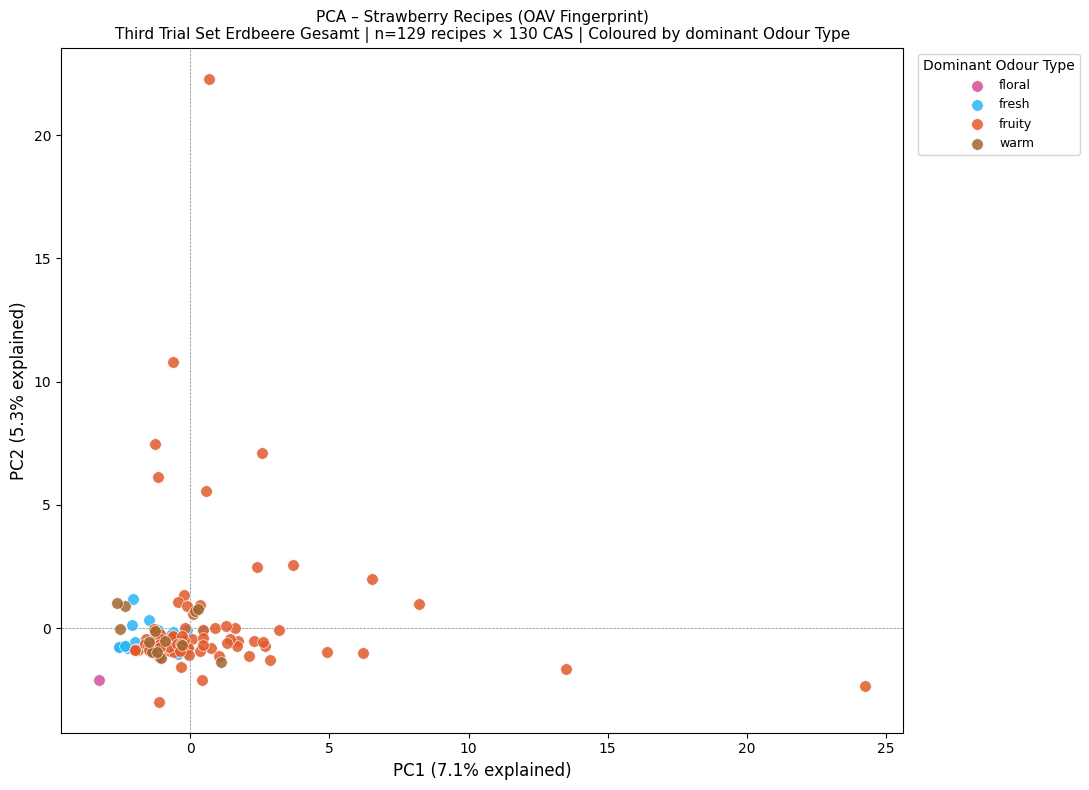

Saved: pca_v1_pc1pc2_oav.png


In [10]:
# ── PC1 vs PC2 scatter – coloured by dominant odour type ────────────────────
fig, ax = plt.subplots(figsize=(11, 8))

for ot in sorted(set(dom_ot_labels)):
    mask = np.array(dom_ot_labels) == ot
    ax.scatter(
        scores_oav[mask, 0], scores_oav[mask, 1],
        c=ODOUR_PALETTE.get(ot, '#BBBBBB'),
        label=ot, s=70, alpha=0.85, edgecolors='white', linewidths=0.5, zorder=3
    )

ax.axhline(0, color='grey', lw=0.5, ls='--')
ax.axvline(0, color='grey', lw=0.5, ls='--')
ax.set_xlabel(f'PC1 ({ev[0]:.1f}% explained)', fontsize=12)
ax.set_ylabel(f'PC2 ({ev[1]:.1f}% explained)', fontsize=12)
ax.set_title(
    'PCA – Strawberry Recipes (OAV Fingerprint)\n'
    f'Third Trial Set Erdbeere Gesamt | n={len(recipes_oav)} recipes × 130 CAS | Coloured by dominant Odour Type',
    fontsize=11
)
ax.legend(title='Dominant Odour Type', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
fig.savefig(OUT_DIR / 'pca_v1_pc1pc2_oav.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pca_v1_pc1pc2_oav.png')

## 3 · Biplot – Top Ingredient Loadings

In [11]:
# ── Build ingredient name lookup ─────────────────────────────────────────────
cas_name = df.groupby('CAS-Nr.')['Name'].first().to_dict()

# Loadings matrix: shape (n_components, n_features)
loadings = pca_oav.components_  # (10, 130)
cas_labels = pivot_oav.columns.tolist()

# Identify top contributors to PC1 and PC2
N_ARROWS = 12
importance = np.sqrt(loadings[0]**2 + loadings[1]**2)
top_idx = np.argsort(importance)[::-1][:N_ARROWS]

print(f'Top {N_ARROWS} ingredients driving PC1+PC2:')
for i in top_idx:
    cas = cas_labels[i]
    name = cas_name.get(cas, cas)
    print(f'  {cas:15s} {name[:45]:45s}  L1={loadings[0,i]:+.3f}  L2={loadings[1,i]:+.3f}')

Top 12 ingredients driving PC1+PC2:
  7212-44-4       Nerolidol                                      L1=-0.005  L2=+0.341
  110-93-0        Methylheptenon, natürlich Kosher; Halal V;     L1=-0.004  L2=+0.341
  71-36-3         Butanol, natürlich Halal                       L1=-0.004  L2=+0.341
  2639-63-6       Hexylbutyrat Halal Kosher                      L1=-0.003  L2=+0.340
  14901-07-6      beta-Ionon Halal Kosher                        L1=-0.004  L2=+0.337
  105-54-4        Ethylbutyrat Kosher Halal                      L1=+0.290  L2=-0.008
  142-62-1        Hexansäure kräftig                             L1=+0.281  L2=+0.059
  116-53-0        2-Methylbuttersäure Halal Kosher               L1=+0.285  L2=-0.005
  513-86-0        Acetoin 50% in PG Kosher Halal                 L1=-0.012  L2=+0.281
  706-14-9        gamma-Decalacton Kosher Halal                  L1=+0.275  L2=+0.006
  123-66-0        Ethylhexanoat Halal                            L1=+0.275  L2=-0.001
  1754-62-7       

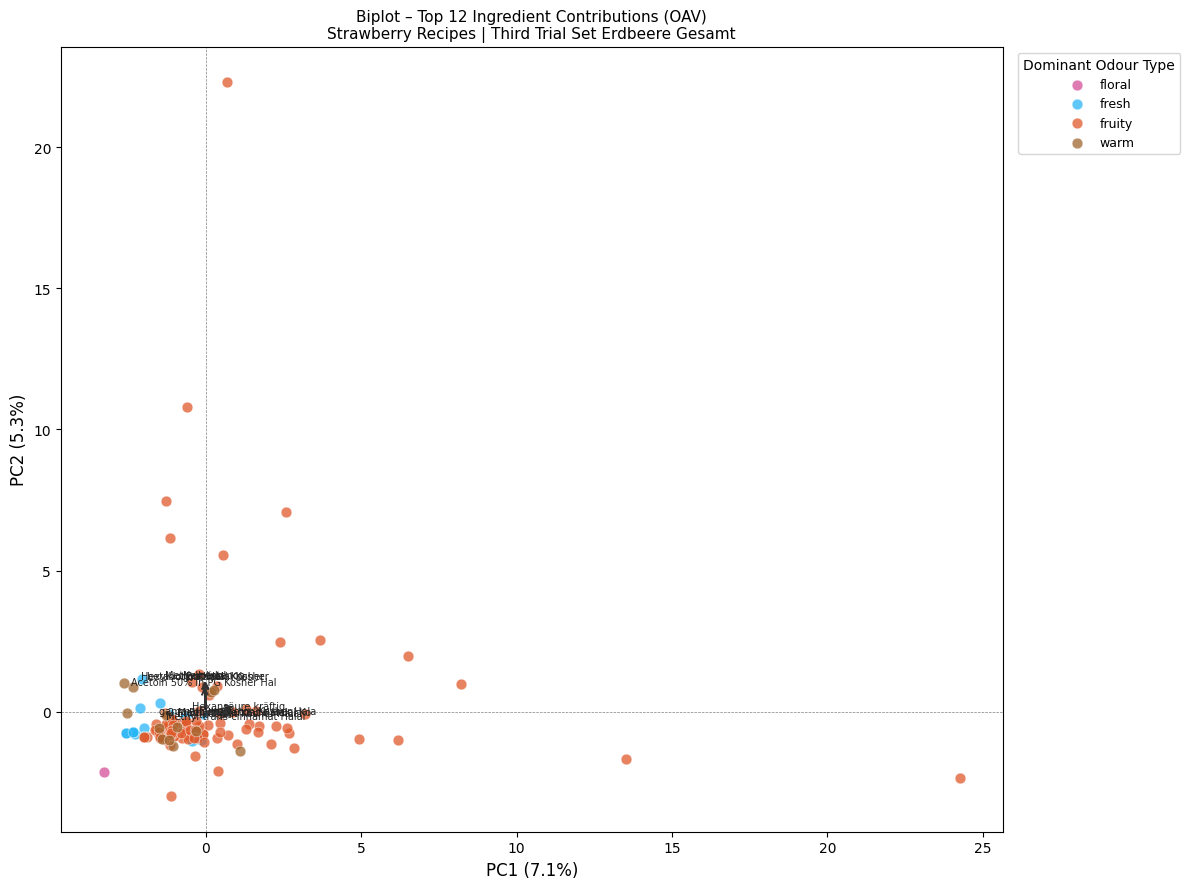

Saved: pca_v1_biplot_oav.png


In [12]:
# ── Biplot ───────────────────────────────────────────────────────────────────
SCALE = 3.5  # scale factor to make arrows visible

fig, ax = plt.subplots(figsize=(12, 9))

# Scatter recipes
for ot in sorted(set(dom_ot_labels)):
    mask = np.array(dom_ot_labels) == ot
    ax.scatter(
        scores_oav[mask, 0], scores_oav[mask, 1],
        c=ODOUR_PALETTE.get(ot, '#BBBBBB'),
        label=ot, s=60, alpha=0.75, edgecolors='white', linewidths=0.4, zorder=3
    )

# Arrow overlays for top ingredients
for i in top_idx:
    cas = cas_labels[i]
    name = cas_name.get(cas, cas)
    # Shorten name for readability
    short = name.split(',')[0][:28]
    lx, ly = loadings[0, i] * SCALE, loadings[1, i] * SCALE
    ax.annotate(
        '', xy=(lx, ly), xytext=(0, 0),
        arrowprops=dict(arrowstyle='->', color='#333333', lw=1.4)
    )
    ax.text(lx * 1.08, ly * 1.08, short, fontsize=7, color='#222222',
            ha='center', va='center')

ax.axhline(0, color='grey', lw=0.5, ls='--')
ax.axvline(0, color='grey', lw=0.5, ls='--')
ax.set_xlabel(f'PC1 ({ev[0]:.1f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({ev[1]:.1f}%)', fontsize=12)
ax.set_title(
    f'Biplot – Top {N_ARROWS} Ingredient Contributions (OAV)\n'
    'Strawberry Recipes | Third Trial Set Erdbeere Gesamt',
    fontsize=11
)
ax.legend(title='Dominant Odour Type', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
fig.savefig(OUT_DIR / 'pca_v1_biplot_oav.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pca_v1_biplot_oav.png')

## 4 · PCA on Odour-Type Profile

In [13]:
# ── Fit PCA on odour-type matrix ─────────────────────────────────────────────
scaler_ot = StandardScaler()
X_ot_scaled = scaler_ot.fit_transform(X_ot)

n_comp_ot = min(10, X_ot.shape[1], X_ot.shape[0])
pca_ot = PCA(n_components=n_comp_ot, random_state=42)
scores_ot = pca_ot.fit_transform(X_ot_scaled)

ev_ot = pca_ot.explained_variance_ratio_ * 100
print('Explained variance (Odour-Type PCA):')
for i, v in enumerate(ev_ot):
    print(f'  PC{i+1}: {v:.1f}%  (cumulative: {ev_ot[:i+1].sum():.1f}%)')

Explained variance (Odour-Type PCA):
  PC1: 48.3%  (cumulative: 48.3%)
  PC2: 14.7%  (cumulative: 63.0%)
  PC3: 9.8%  (cumulative: 72.8%)
  PC4: 8.6%  (cumulative: 81.4%)
  PC5: 8.3%  (cumulative: 89.7%)
  PC6: 3.5%  (cumulative: 93.2%)
  PC7: 3.2%  (cumulative: 96.5%)
  PC8: 1.8%  (cumulative: 98.3%)
  PC9: 1.1%  (cumulative: 99.4%)
  PC10: 0.5%  (cumulative: 99.8%)


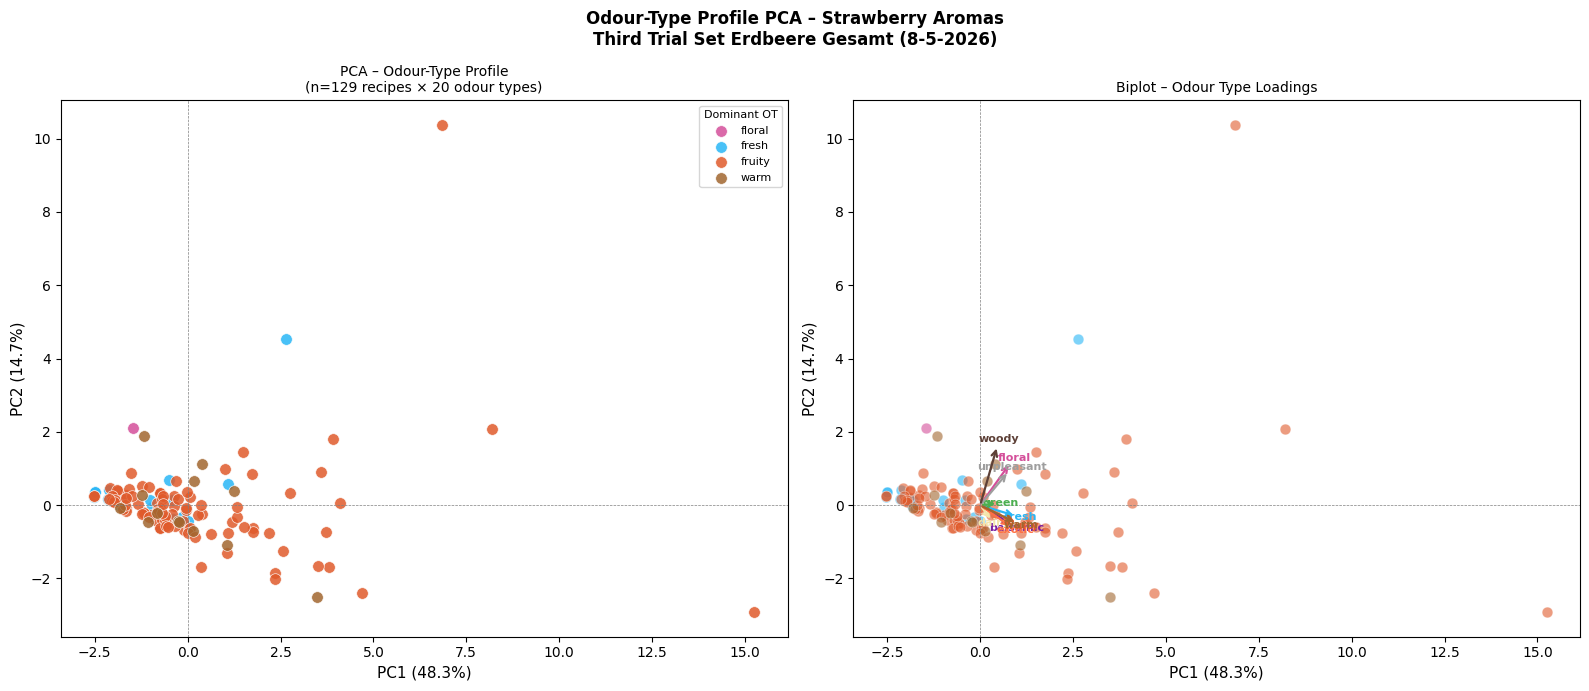

Saved: pca_v1_odourtype_biplot.png


In [14]:
# ── PC1 vs PC2 – Odour Type space ────────────────────────────────────────────
recipes_ot = list(pivot_ot.index)
dom_ot_ot  = [dom_ot_dict.get(r, 'unknown') for r in recipes_ot]
colors_ot  = [ODOUR_PALETTE.get(ot, '#BBBBBB') for ot in dom_ot_ot]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Left: Odour-type PCA scatter ---
ax = axes[0]
for ot in sorted(set(dom_ot_ot)):
    mask = np.array(dom_ot_ot) == ot
    ax.scatter(
        scores_ot[mask, 0], scores_ot[mask, 1],
        c=ODOUR_PALETTE.get(ot, '#BBBBBB'),
        label=ot, s=70, alpha=0.85, edgecolors='white', linewidths=0.5
    )
ax.axhline(0, color='grey', lw=0.5, ls='--')
ax.axvline(0, color='grey', lw=0.5, ls='--')
ax.set_xlabel(f'PC1 ({ev_ot[0]:.1f}%)', fontsize=11)
ax.set_ylabel(f'PC2 ({ev_ot[1]:.1f}%)', fontsize=11)
ax.set_title('PCA – Odour-Type Profile\n(n={} recipes × 20 odour types)'.format(len(recipes_ot)), fontsize=10)
ax.legend(title='Dominant OT', fontsize=8, title_fontsize=8)

# --- Right: Odour-type loadings biplot ---
ax2 = axes[1]
for ot in sorted(set(dom_ot_ot)):
    mask = np.array(dom_ot_ot) == ot
    ax2.scatter(
        scores_ot[mask, 0], scores_ot[mask, 1],
        c=ODOUR_PALETTE.get(ot, '#BBBBBB'),
        s=60, alpha=0.6, edgecolors='white', linewidths=0.4
    )

SCALE_OT = 2.5
loadings_ot = pca_ot.components_
ot_cols = list(pivot_ot.columns)
for j, ot_name in enumerate(ot_cols):
    lx, ly = loadings_ot[0, j] * SCALE_OT, loadings_ot[1, j] * SCALE_OT
    if abs(lx) + abs(ly) < 0.3:  # skip tiny arrows
        continue
    ax2.annotate(
        '', xy=(lx, ly), xytext=(0, 0),
        arrowprops=dict(arrowstyle='->', color=ODOUR_PALETTE.get(ot_name,'#555'), lw=1.6)
    )
    ax2.text(lx * 1.12, ly * 1.12, ot_name, fontsize=8,
             color=ODOUR_PALETTE.get(ot_name,'#333'),
             ha='center', va='center', fontweight='bold')

ax2.axhline(0, color='grey', lw=0.5, ls='--')
ax2.axvline(0, color='grey', lw=0.5, ls='--')
ax2.set_xlabel(f'PC1 ({ev_ot[0]:.1f}%)', fontsize=11)
ax2.set_ylabel(f'PC2 ({ev_ot[1]:.1f}%)', fontsize=11)
ax2.set_title('Biplot – Odour Type Loadings', fontsize=10)

fig.suptitle(
    'Odour-Type Profile PCA – Strawberry Aromas\nThird Trial Set Erdbeere Gesamt (8-5-2026)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
fig.savefig(OUT_DIR / 'pca_v1_odourtype_biplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pca_v1_odourtype_biplot.png')

## 5 · PC1–PC3 Dashboard (3 Panel)

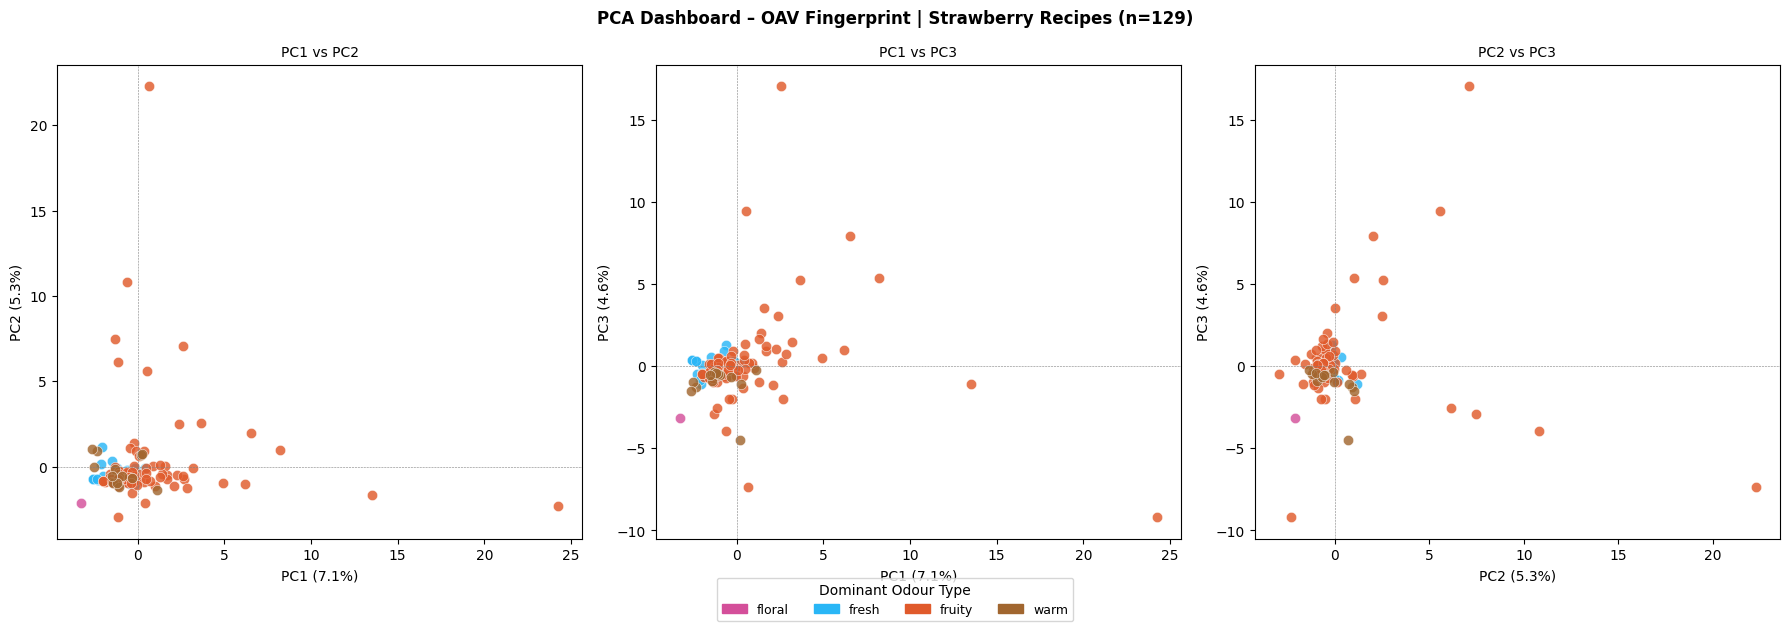

Saved: pca_v1_dashboard_pc123.png


In [15]:
# ── PC1 vs PC2, PC1 vs PC3, PC2 vs PC3 ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

pairs = [(0, 1), (0, 2), (1, 2)]

for ax, (i, j) in zip(axes, pairs):
    for ot in sorted(set(dom_ot_labels)):
        mask = np.array(dom_ot_labels) == ot
        ax.scatter(
            scores_oav[mask, i], scores_oav[mask, j],
            c=ODOUR_PALETTE.get(ot, '#BBBBBB'),
            label=ot, s=55, alpha=0.82, edgecolors='white', linewidths=0.4
        )
    ax.axhline(0, color='grey', lw=0.4, ls='--')
    ax.axvline(0, color='grey', lw=0.4, ls='--')
    ax.set_xlabel(f'PC{i+1} ({ev[i]:.1f}%)', fontsize=10)
    ax.set_ylabel(f'PC{j+1} ({ev[j]:.1f}%)', fontsize=10)
    ax.set_title(f'PC{i+1} vs PC{j+1}', fontsize=10)

# Shared legend
handles = [
    mpatches.Patch(color=ODOUR_PALETTE.get(ot,'#BBBBBB'), label=ot)
    for ot in sorted(set(dom_ot_labels))
]
fig.legend(handles=handles, title='Dominant Odour Type',
           loc='lower center', ncol=6, fontsize=9,
           bbox_to_anchor=(0.5, -0.05))
fig.suptitle(
    'PCA Dashboard – OAV Fingerprint | Strawberry Recipes (n=129)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
fig.savefig(OUT_DIR / 'pca_v1_dashboard_pc123.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pca_v1_dashboard_pc123.png')

## 6 · Loading Heatmap – Which Ingredients Drive Which Components

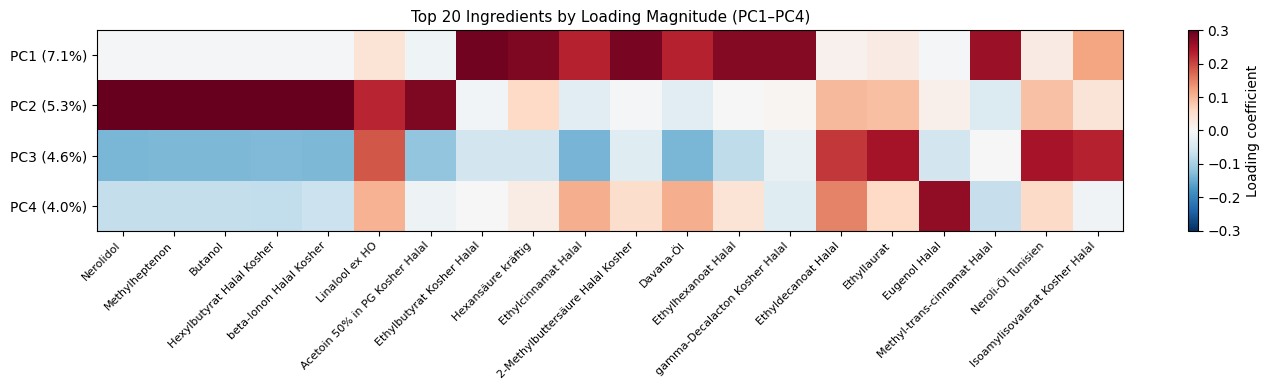

Saved: pca_v1_loading_heatmap.png


In [16]:
# Top 20 ingredients by combined importance across PC1..PC4
N_TOP = 20
N_PC  = min(4, pca_oav.n_components_)

importance_4 = np.sqrt((loadings[:N_PC]**2).sum(axis=0))
top20_idx = np.argsort(importance_4)[::-1][:N_TOP]

top20_cas   = [cas_labels[i] for i in top20_idx]
top20_names = [cas_name.get(c, c).split(',')[0][:35] for c in top20_cas]
loading_mat = loadings[:N_PC][:, top20_idx]  # (N_PC, N_TOP)

fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(loading_mat, aspect='auto', cmap='RdBu_r', vmin=-0.3, vmax=0.3)
ax.set_xticks(range(N_TOP))
ax.set_xticklabels(top20_names, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(N_PC))
ax.set_yticklabels([f'PC{k+1} ({ev[k]:.1f}%)' for k in range(N_PC)], fontsize=10)
plt.colorbar(im, ax=ax, label='Loading coefficient')
ax.set_title(f'Top {N_TOP} Ingredients by Loading Magnitude (PC1–PC{N_PC})', fontsize=11)
plt.tight_layout()
fig.savefig(OUT_DIR / 'pca_v1_loading_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pca_v1_loading_heatmap.png')

## 7 · Recipe Scores Table

In [17]:
# Full scores table for reference / export
scores_df = pd.DataFrame(
    scores_oav[:, :5],
    index=pivot_oav.index,
    columns=[f'PC{i+1}' for i in range(5)]
)
scores_df['Dominant_OT'] = dom_ot_labels
scores_df.index.name = 'Rez.-Nr.'

print('PCA Scores (first 15 recipes):')
print(scores_df.head(15).round(3).to_string())

scores_df.to_csv(OUT_DIR / 'pca_v1_scores.csv')
print('\nFull table saved: pca_v1_scores.csv')

PCA Scores (first 15 recipes):
             PC1    PC2    PC3    PC4    PC5 Dominant_OT
Rez.-Nr.                                                
185.028   -2.280 -0.791 -0.507  0.625 -0.354       fresh
185.043P  -2.340 -0.709  0.335  0.844 -1.013       fresh
185.044   -2.340 -0.705  0.334  0.844 -1.013       fresh
185.046   -1.994 -0.570  0.086  0.891  1.504       fresh
185.086   -1.288 -0.116 -0.353  0.065 -0.409        warm
185.090P  -1.139 -1.160 -0.992  0.928  0.167      fruity
185.091   -1.104 -0.274 -0.078 -0.192 -0.223      fruity
185.133   -1.169 -0.529 -0.308  0.600 -0.298      fruity
185.178HP -1.103 -0.273 -0.078 -0.193 -0.224      fruity
185.237H  -0.076 -0.783 -0.113 -0.172  0.149      fruity
185.239   -0.748 -0.907 -0.284 -0.691 -0.208      fruity
185.267    0.357  0.934 -0.602  1.555  1.118      fruity
185.291   -1.483 -0.654 -0.204  0.231  0.060       fresh
185.294   -0.784 -0.398 -0.158  0.223 -0.387      fruity
185.309P  -3.279 -2.120 -3.168  6.365 -0.797      floral


---
## Summary  

| | Value |
|---|---|
| Recipes analysed | 129 |
| Ingredients with OAV | 130 CAS |
| PC1 explained variance | 7.1% |
| PC2 explained variance | 5.3% |
| PC1+PC2 cumulative | 12.5% |
| PC1+PC2+PC3 cumulative | 17.1% |
| Odour-type PC1 | 48.3% |
| Odour-type PC1+PC2 | 63.0% |

**Output files:**
- `outputs/pca_v1_scree_oav.png`
- `outputs/pca_v1_pc1pc2_oav.png`
- `outputs/pca_v1_biplot_oav.png`
- `outputs/pca_v1_odourtype_biplot.png`
- `outputs/pca_v1_dashboard_pc123.png`
- `outputs/pca_v1_loading_heatmap.png`
- `outputs/pca_v1_contrib_heatmap_pc1.png`
- `outputs/pca_v1_scores.csv`
- `outputs/pca_v1_recipe_attribution.csv`

In [18]:
# ── Pre-compute full contribution tensor: (n_recipes, n_pc, n_cas) ──────────
# contrib[r, k, i] = X_oav_scaled[r,i] * loadings[k,i]
N_PC_ATTR = 4
contrib = X_oav_scaled[:, np.newaxis, :] * loadings[np.newaxis, :N_PC_ATTR, :]  # (R, K, I)

recipe_idx_map = {r: idx for idx, r in enumerate(recipes_oav)}
cas_name       = df.groupby('CAS-Nr.')['Name'].first().to_dict()

print(f'Contribution tensor shape: {contrib.shape}  (recipes × PCs × ingredients)')
print('Ready for recipe lookup.')

Contribution tensor shape: (129, 4, 130)  (recipes × PCs × ingredients)
Ready for recipe lookup.


In [19]:
def explain_recipe(rez_nr, n_top=8, plot=True):
    """
    Given a recipe (Rez.-Nr.), print and optionally plot:
      - its PC1–PC4 scores
      - the top n_top ingredients driving each PC (by signed contribution)
      - the 8 nearest recipes in PCA space
    """
    if rez_nr not in recipe_idx_map:
        print(f'Recipe {rez_nr!r} not found.')
        print('Available (first 10):', sorted(recipe_idx_map.keys())[:10])
        return

    r_idx   = recipe_idx_map[rez_nr]
    r_scores = scores_oav[r_idx, :N_PC_ATTR]
    r_contrib = contrib[r_idx]          # shape (N_PC_ATTR, n_cas)
    dom_ot  = dom_ot_labels[r_idx]

    print('══════════════════════════════════════════════════')
    print(f'  Recipe: {rez_nr}   |   Dominant Odour Type: {dom_ot}')
    print('══════════════════════════════════════════════════')
    for k in range(N_PC_ATTR):
        print(f'  PC{k+1} score: {r_scores[k]:+.3f}  (explains {ev[k]:.1f}% of total variance)')
    print()

    # ── Top ingredients per PC ────────────────────────────────────────────
    for k in range(N_PC_ATTR):
        c_vec   = r_contrib[k]
        top_idx_k = np.argsort(np.abs(c_vec))[::-1][:n_top]
        print(f'  ── PC{k+1}: top {n_top} ingredient drivers ──')
        for i in top_idx_k:
            cas  = cas_labels[i]
            name = cas_name.get(cas, cas).split(',')[0][:40]
            oav  = pivot_oav.iloc[r_idx, i]
            sign = '+' if c_vec[i] >= 0 else '-'
            print(f'    {sign}  contrib={c_vec[i]:+.4f}  OAV={oav:.5f}  {name} ({cas})')
        print()

    # ── Nearest recipes ───────────────────────────────────────────────────
    dists   = np.linalg.norm(scores_oav - scores_oav[r_idx], axis=1)
    nn_idx  = np.argsort(dists)[1:9]
    print('  ── 8 nearest recipes in PCA space ──')
    for ni in nn_idx:
        print(f'    {recipes_oav[ni]:12s}  dist={dists[ni]:.3f}'
              f'  PC1={scores_oav[ni,0]:+.2f}  PC2={scores_oav[ni,1]:+.2f}'
              f'  ({dom_ot_labels[ni]})')

    # ── Bar chart: PC1 & PC2 ingredient contributions ────────────────────
    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        for ax_i, k in enumerate([0, 1]):
            c_vec     = r_contrib[k]
            top_idx_k = np.argsort(np.abs(c_vec))[::-1][:n_top]
            names_k   = [cas_name.get(cas_labels[i], cas_labels[i]).split(',')[0][:32]
                         for i in top_idx_k]
            vals_k    = [c_vec[i] for i in top_idx_k]
            bar_colors = ['#E05A2B' if v >= 0 else '#4A90D9' for v in vals_k]
            ax = axes[ax_i]
            ax.barh(range(n_top), vals_k[::-1], color=bar_colors[::-1],
                    edgecolor='white', height=0.7)
            ax.set_yticks(range(n_top))
            ax.set_yticklabels(names_k[::-1], fontsize=8)
            ax.axvline(0, color='grey', lw=0.8)
            ax.set_xlabel('Contribution to PC score')
            ax.set_title(f'PC{k+1} ({ev[k]:.1f}%) — recipe {rez_nr}')
        fig.suptitle(
            f'Ingredient Attribution  |  Recipe {rez_nr}  |  Dominant OT: {dom_ot}',
            fontsize=11, fontweight='bold'
        )
        plt.tight_layout()
        safe = str(rez_nr).replace('.', '-').replace(' ', '_')
        fname = OUT_DIR / f'pca_v1_explain_{safe}.png'
        fig.savefig(fname, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'Saved: {fname.name}')

print('explain_recipe() defined.')
print('Usage:  explain_recipe(recipes_oav[0])')

explain_recipe() defined.
Usage:  explain_recipe(recipes_oav[0])


══════════════════════════════════════════════════
  Recipe: 185.028   |   Dominant Odour Type: fresh
══════════════════════════════════════════════════
  PC1 score: -2.280  (explains 7.1% of total variance)
  PC2 score: -0.791  (explains 5.3% of total variance)
  PC3 score: -0.507  (explains 4.6% of total variance)
  PC4 score: +0.625  (explains 4.0% of total variance)

  ── PC1: top 8 ingredient drivers ──
    -  contrib=-0.2454  OAV=0.00003  beta-Damascenon (23696-85-7)
    -  contrib=-0.1988  OAV=0.01164  Ethylbutyrat Kosher Halal (105-54-4)
    -  contrib=-0.1988  OAV=0.00140  Ethyl-trans (3025-30-7)
    -  contrib=-0.1876  OAV=0.00219  Ethyl-2-methylbutyrat Kosher Halal (7452-79-1)
    -  contrib=-0.1811  OAV=0.00437  gamma-Decalacton Kosher Halal (706-14-9)
    -  contrib=-0.1358  OAV=0.00227  Hexansäure kräftig (142-62-1)
    -  contrib=-0.1298  OAV=0.00402  Ethylhexanoat Halal (123-66-0)
    -  contrib=-0.1150  OAV=0.00000  Methyl-trans-cinnamat Halal (1754-62-7)

  ── PC2: to

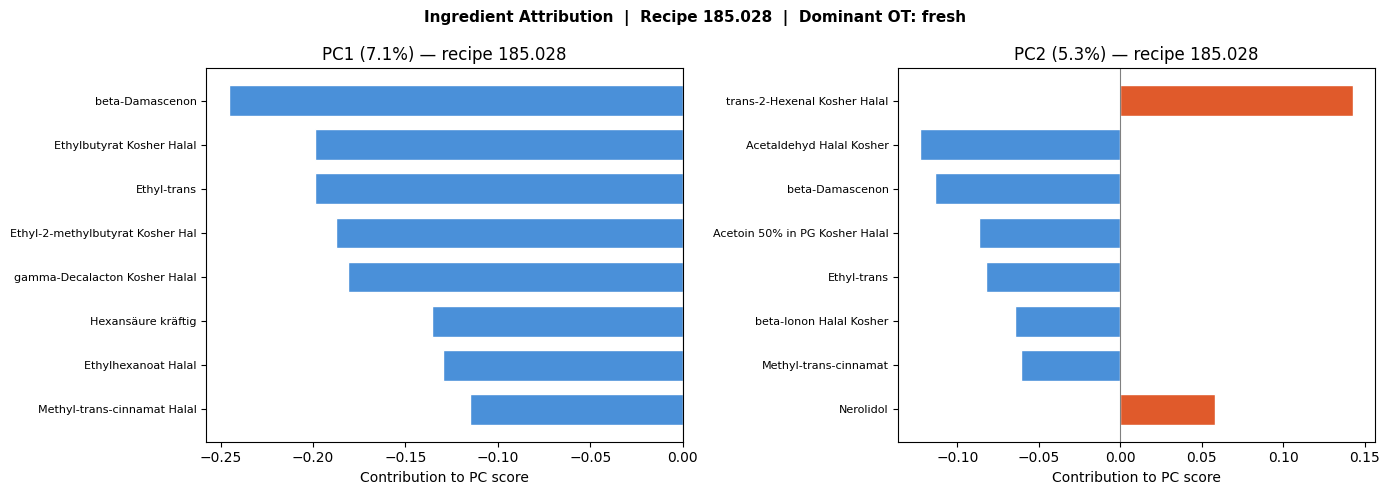

Saved: pca_v1_explain_185-028.png

══════════════════════════════════════════════════
  Recipe: 185.043P   |   Dominant Odour Type: fresh
══════════════════════════════════════════════════
  PC1 score: -2.340  (explains 7.1% of total variance)
  PC2 score: -0.709  (explains 5.3% of total variance)
  PC3 score: +0.335  (explains 4.6% of total variance)
  PC4 score: +0.844  (explains 4.0% of total variance)

  ── PC1: top 8 ingredient drivers ──
    -  contrib=-0.2637  OAV=0.00184  Ethyl-trans (3025-30-7)
    -  contrib=-0.2617  OAV=0.00001  Isobuttersäure (79-31-2)
    -  contrib=-0.1889  OAV=0.01739  Ethylbutyrat Kosher Halal (105-54-4)
    -  contrib=-0.1855  OAV=0.00283  Ethyl-2-methylbutyrat Kosher Halal (7452-79-1)
    -  contrib=-0.1695  OAV=0.00700  gamma-Decalacton Kosher Halal (706-14-9)
    -  contrib=-0.1270  OAV=0.00002  2-Methylbuttersäure Halal Kosher (116-53-0)
    -  contrib=-0.1262  OAV=0.00543  Ethylhexanoat Halal (123-66-0)
    -  contrib=-0.1150  OAV=0.00000  Methyl-

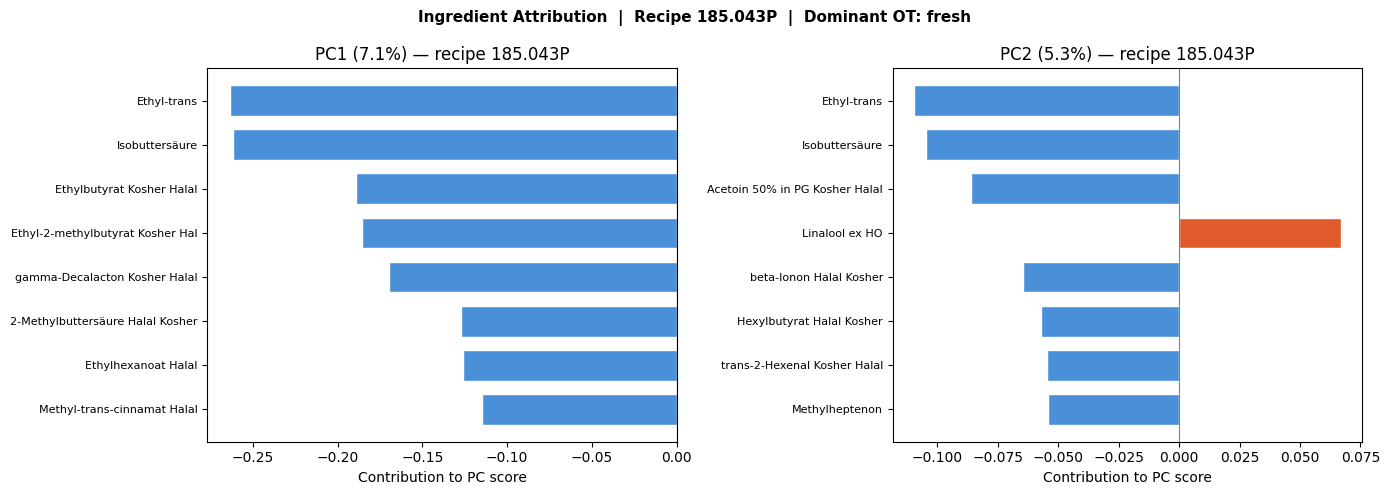

Saved: pca_v1_explain_185-043P.png

══════════════════════════════════════════════════
  Recipe: 185.044   |   Dominant Odour Type: fresh
══════════════════════════════════════════════════
  PC1 score: -2.340  (explains 7.1% of total variance)
  PC2 score: -0.705  (explains 5.3% of total variance)
  PC3 score: +0.334  (explains 4.6% of total variance)
  PC4 score: +0.844  (explains 4.0% of total variance)

  ── PC1: top 8 ingredient drivers ──
    -  contrib=-0.2637  OAV=0.00184  Ethyl-trans (3025-30-7)
    -  contrib=-0.2617  OAV=0.00001  Isobuttersäure (79-31-2)
    -  contrib=-0.1889  OAV=0.01739  Ethylbutyrat Kosher Halal (105-54-4)
    -  contrib=-0.1855  OAV=0.00283  Ethyl-2-methylbutyrat Kosher Halal (7452-79-1)
    -  contrib=-0.1695  OAV=0.00700  gamma-Decalacton Kosher Halal (706-14-9)
    -  contrib=-0.1270  OAV=0.00002  2-Methylbuttersäure Halal Kosher (116-53-0)
    -  contrib=-0.1262  OAV=0.00543  Ethylhexanoat Halal (123-66-0)
    -  contrib=-0.1150  OAV=0.00000  Methyl-

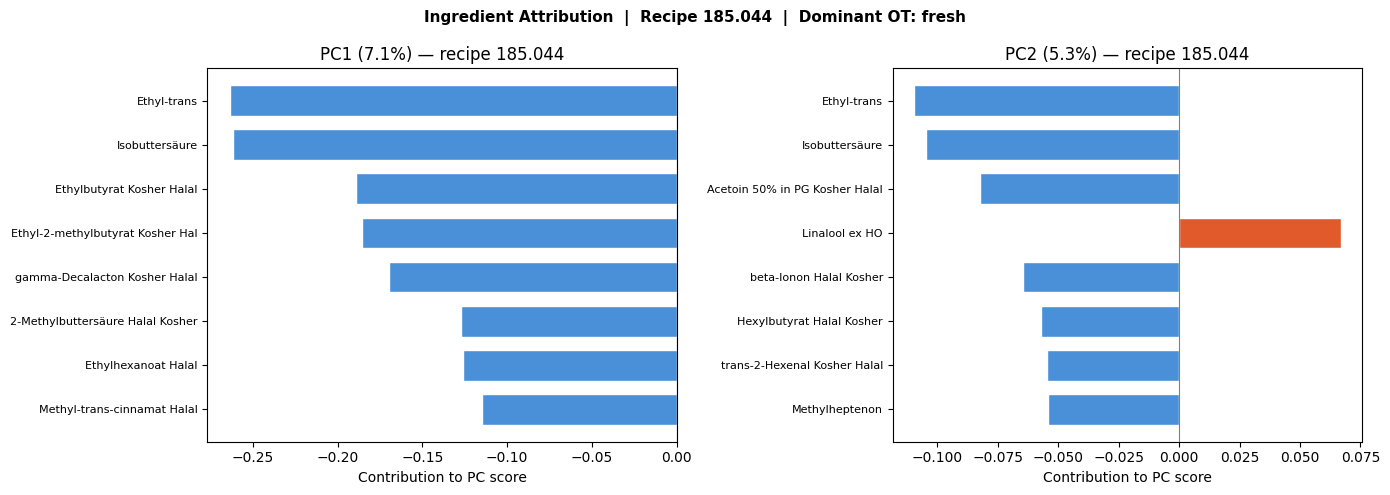

Saved: pca_v1_explain_185-044.png



In [20]:
# ── Demo: explain first 3 recipes ────────────────────────────────────────────
for demo_rez in recipes_oav[:3]:
    explain_recipe(demo_rez, n_top=8, plot=True)
    print()

---
## 9 · Ingredient → Recipe Lookup

**Which recipes are most strongly characterised by a given ingredient?**

Search by CAS number or name fragment (case-insensitive). Recipes are ranked by
their OAV for that ingredient and highlighted in the PCA map — marker size scales
with OAV so the most "ingredient-dominant" recipes stand out immediately.

In [21]:
def find_by_ingredient(query, n_top=15, plot=True):
    """
    Find recipes containing a given ingredient.

    Parameters
    ----------
    query : str
        Exact CAS number  OR  a substring of the ingredient name (case-insensitive).
    n_top : int
        How many recipes to show, ranked by OAV.
    plot : bool
        Highlight matching recipes in the PC1/PC2 map.

    Returns
    -------
    pd.DataFrame  with columns: OAV, log1p(OAV), PC1, PC2, PC3, Dom. OT
    """
    q = str(query).strip()

    # Resolve query → list of CAS numbers
    if q in cas_labels:                   # exact CAS match
        matched_cas = [q]
    else:                                  # name substring match
        matched_cas = [c for c in cas_labels if q.lower() in cas_name.get(c,'').lower()]

    if not matched_cas:
        print(f'No ingredient found matching {q!r}.')
        print('Tip: try a partial name like "furaneol", "vanillin", "linalool", "butyrate"')
        return None

    print(f'Matched {len(matched_cas)} CAS number(s):')
    for cas in matched_cas:
        print(f'  {cas}  →  {cas_name.get(cas, cas)}')
    print()

    # Sum OAV across all matched CAS per recipe
    oav_per_recipe = pivot_oav[matched_cas].sum(axis=1)
    oav_nonzero    = oav_per_recipe[oav_per_recipe > 0].sort_values(ascending=False)
    print(f'Present in {len(oav_nonzero)} / {len(recipes_oav)} recipes.')
    print()

    # Build result table
    table_rows = []
    for rez, oav_val in oav_nonzero.head(n_top).items():
        ri = recipe_idx_map[rez]
        table_rows.append({
            'Rez.-Nr.':   rez,
            'OAV':        round(oav_val, 6),
            'log1p(OAV)': round(float(np.log1p(oav_val)), 3),
            'PC1':        round(scores_oav[ri, 0], 3),
            'PC2':        round(scores_oav[ri, 1], 3),
            'PC3':        round(scores_oav[ri, 2], 3),
            'Dom. OT':    dom_ot_labels[ri],
        })

    result_df = pd.DataFrame(table_rows).set_index('Rez.-Nr.')
    print(f'Top {min(n_top, len(oav_nonzero))} recipes by OAV:')
    print(result_df.to_string())
    print()

    if plot:
        fig, ax = plt.subplots(figsize=(11, 8))

        # Background: all recipes in grey
        ax.scatter(scores_oav[:, 0], scores_oav[:, 1],
                   c='#CCCCCC', s=35, alpha=0.45, zorder=1, label='Other recipes')

        # Highlight recipes containing this ingredient
        hi_idx  = [recipe_idx_map[r] for r in oav_nonzero.index if r in recipe_idx_map]
        hi_oavs = oav_nonzero.loc[[r for r in oav_nonzero.index if r in recipe_idx_map]].values
        # Marker size proportional to log(OAV)
        log_oavs = np.log1p(hi_oavs)
        sizes = 50 + 220 * (log_oavs - log_oavs.min()) / (log_oavs.max() - log_oavs.min() + 1e-9)

        sc = ax.scatter(
            scores_oav[hi_idx, 0], scores_oav[hi_idx, 1],
            c=hi_oavs, cmap='YlOrRd', norm=plt.matplotlib.colors.LogNorm(),
            s=sizes, alpha=0.92, edgecolors='#333', linewidths=0.7,
            zorder=3, label='Contains ingredient'
        )
        plt.colorbar(sc, ax=ax, label='OAV (log scale)')

        # Label top-6 recipes
        for r in oav_nonzero.head(6).index:
            if r not in recipe_idx_map:
                continue
            ri = recipe_idx_map[r]
            ax.annotate(r, (scores_oav[ri, 0], scores_oav[ri, 1]),
                        fontsize=7, xytext=(5, 5), textcoords='offset points')

        ing_label = ' / '.join(cas_name.get(c, c).split(',')[0][:28] for c in matched_cas[:2])
        ax.set_xlabel(f'PC1 ({ev[0]:.1f}%)', fontsize=11)
        ax.set_ylabel(f'PC2 ({ev[1]:.1f}%)', fontsize=11)
        ax.set_title(
            f'Ingredient Highlight: {ing_label}\n'
            f'Present in {len(oav_nonzero)} / {len(recipes_oav)} recipes  |  '
            f'marker size ∝ OAV',
            fontsize=10
        )
        ax.axhline(0, color='grey', lw=0.4, ls='--')
        ax.axvline(0, color='grey', lw=0.4, ls='--')
        ax.legend(fontsize=9)
        plt.tight_layout()
        safe_q = q[:20].replace('/', '-').replace(' ', '_')
        fname = OUT_DIR / f'pca_v1_ingredient_{safe_q}.png'
        fig.savefig(fname, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'Saved: {fname.name}')

    return result_df

print('find_by_ingredient() defined.')
print('Usage:  find_by_ingredient("furaneol")')
print('        find_by_ingredient("3658-77-3")   # by CAS')
print('        find_by_ingredient("vanillin")')

find_by_ingredient() defined.
Usage:  find_by_ingredient("furaneol")
        find_by_ingredient("3658-77-3")   # by CAS
        find_by_ingredient("vanillin")


Top PC1 driver: 105-54-4 – Ethylbutyrat Kosher Halal

Matched 1 CAS number(s):
  105-54-4  →  Ethylbutyrat Kosher Halal

Present in 128 / 129 recipes.

Top 15 recipes by OAV:
              OAV  log1p(OAV)     PC1    PC2    PC3 Dom. OT
Rez.-Nr.                                                   
187.167P  3.36200       1.473  24.260 -2.336 -9.210  fruity
187.892P  1.10964       0.747  13.516 -1.676 -1.120  fruity
189.075   0.67500       0.516   3.195 -0.089  1.463  fruity
187.571P  0.59710       0.468   2.616 -0.565  0.222  fruity
185.471   0.54693       0.436   2.690 -0.731 -2.026  fruity
187.920P  0.48449       0.395   6.191 -0.998  0.961  fruity
188.992   0.41600       0.348   3.678  2.562  5.214  fruity
189.068   0.38680       0.327  -0.696 -0.260  0.936   fresh
187.886P  0.38385       0.325  -0.212  0.018  0.897  fruity
188.977   0.37500       0.318   2.104 -1.125 -1.177  fruity
185.578P  0.36983       0.315   4.924 -0.974  0.470  fruity
185.615   0.31668       0.275   1.017 -1.136 

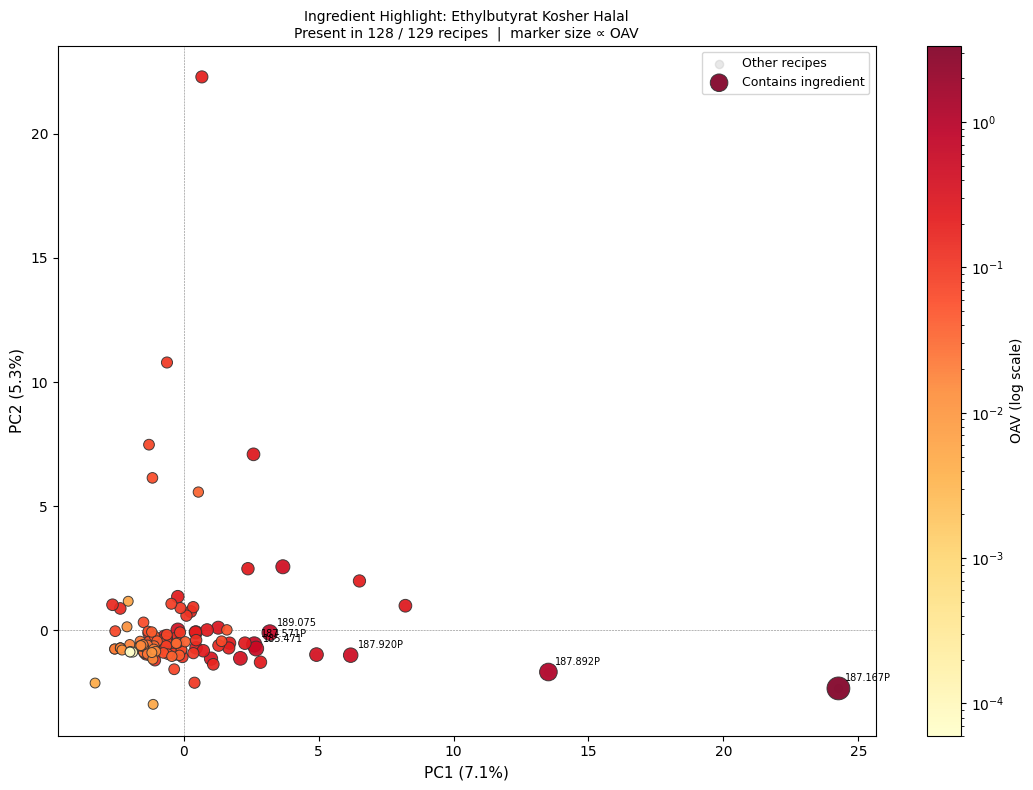

Saved: pca_v1_ingredient_105-54-4.png


In [22]:
# ── Demo: top PC1 driver ingredient ─────────────────────────────────────────
top_pc1_cas = cas_labels[np.argmax(np.abs(loadings[0]))]
print(f'Top PC1 driver: {top_pc1_cas} – {cas_name.get(top_pc1_cas, "?")}')
print()
_ = find_by_ingredient(top_pc1_cas, n_top=15, plot=True)

Matched 1 CAS number(s):
  3658-77-3  →  Furaneol Halal

Present in 103 / 129 recipes.

Top 15 recipes by OAV:
               OAV  log1p(OAV)    PC1    PC2    PC3 Dom. OT
Rez.-Nr.                                                   
187.662P  1.192992       0.785  0.731 -0.820  0.167  fruity
188.822   0.570000       0.451  0.463 -0.701 -0.169  fruity
188.992   0.501000       0.406  3.678  2.562  5.214  fruity
188.491P  0.450000       0.372 -0.491 -0.640 -0.233  fruity
189.075   0.420000       0.351  3.195 -0.089  1.463  fruity
187.608P  0.330357       0.285  1.675 -0.708  1.229  fruity
185.621P  0.326543       0.283  2.272 -0.515  1.060  fruity
187.893P  0.314702       0.274 -0.583 -0.957  0.296  fruity
187.799P  0.306331       0.267 -1.077 -0.235  0.064  fruity
185.644P  0.303667       0.265  1.705 -0.514  0.911  fruity
187.064P  0.300000       0.262  0.871  0.015  0.176  fruity
187.752P  0.257045       0.229 -1.312 -0.041 -0.184  fruity
187.753P  0.257045       0.229 -1.271 -0.440 -0.0

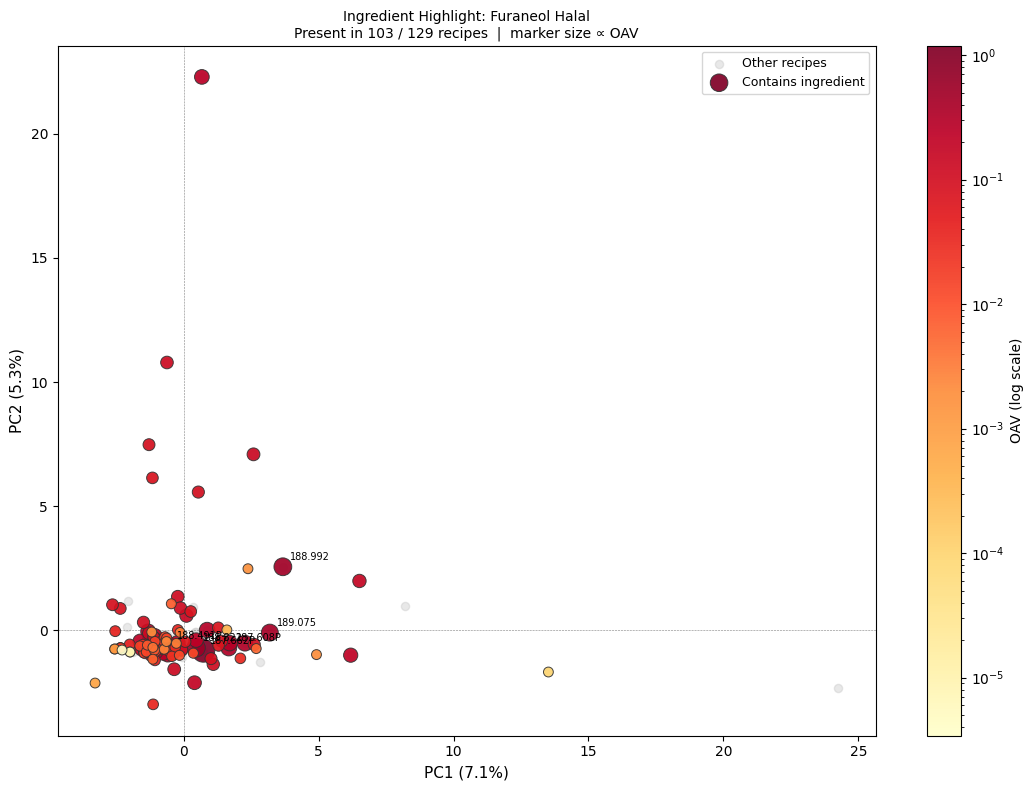

Saved: pca_v1_ingredient_furaneol.png


In [23]:
# ── Demo: Furaneol – the key strawberry character odorant ────────────────────
# 3658-77-3 = 2,5-dimethyl-4-hydroxy-3(2H)-furanone (Furaneol / DMHF)
_ = find_by_ingredient('furaneol', n_top=15, plot=True)

Top PC2 driver: 7212-44-4 – Nerolidol

Matched 1 CAS number(s):
  7212-44-4  →  Nerolidol

Present in 12 / 129 recipes.

Top 12 recipes by OAV:
               OAV  log1p(OAV)    PC1     PC2    PC3 Dom. OT
Rez.-Nr.                                                    
188.628P  0.001928       0.002  0.678  22.287 -7.361  fruity
187.507P  0.000964       0.001 -0.615  10.787 -3.943  fruity
186.395P  0.000694       0.001 -1.281   7.478 -2.924  fruity
186.396P  0.000578       0.001 -1.154   6.141 -2.567  fruity
186.490P  0.000238       0.000 -0.215   1.359 -0.502  fruity
185.028   0.000070       0.000 -2.280  -0.791 -0.507   fresh
185.043P  0.000028       0.000 -2.340  -0.709  0.335   fresh
185.044   0.000028       0.000 -2.340  -0.705  0.334   fresh
188.819   0.000028       0.000 -2.340  -0.705  0.334   fresh
185.507P  0.000004       0.000 -2.347   0.884 -1.258    warm
186.179P  0.000004       0.000 -2.633   1.033 -1.510    warm
185.796P  0.000002       0.000 -2.533  -0.031 -0.951    warm



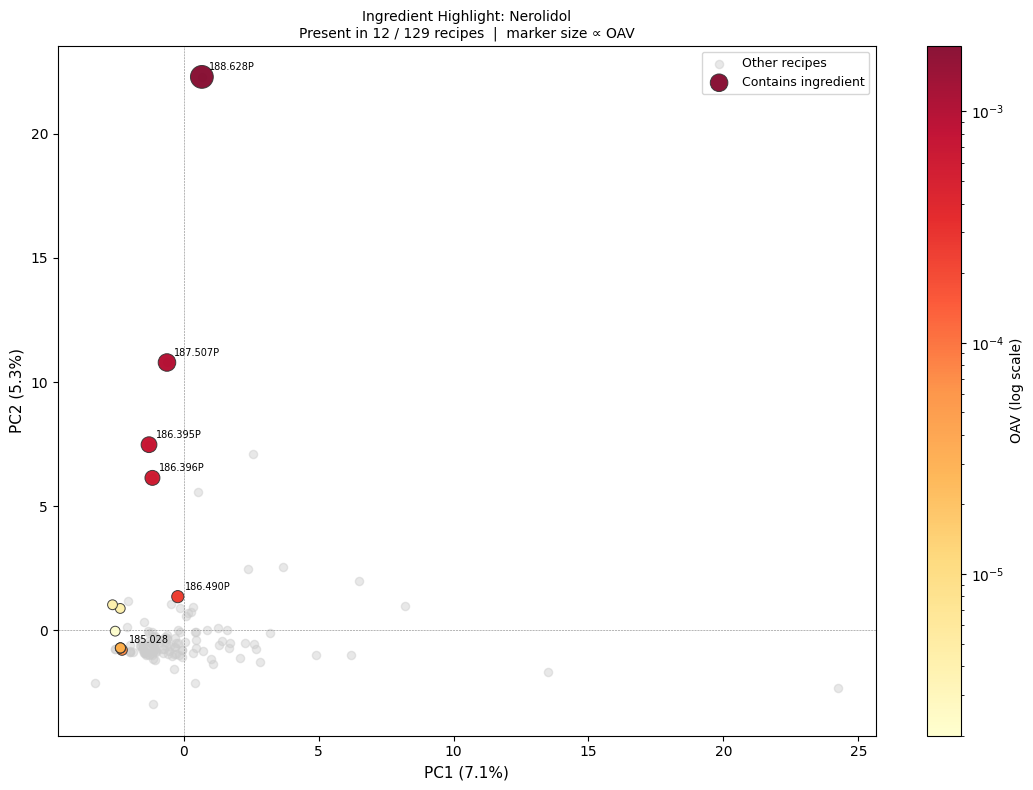

Saved: pca_v1_ingredient_7212-44-4.png


In [24]:
# ── Demo: top PC2 driver ingredient ─────────────────────────────────────────
top_pc2_cas = cas_labels[np.argmax(np.abs(loadings[1]))]
print(f'Top PC2 driver: {top_pc2_cas} – {cas_name.get(top_pc2_cas, "?")}')
print()
_ = find_by_ingredient(top_pc2_cas, n_top=15, plot=True)

---
## 10 · Virtual Recipe → Nearest Real Recipes

**Inverse search:** specify any combination of ingredients and amounts → the model
projects them into PCA space and returns the closest real recipes.

This answers: *"If I build a recipe with these key odorants, which existing recipes
am I closest to — and which odour type family does that land me in?"*

In [25]:
def nearest_recipes(ingredient_dict, n=10, plot=True, label='Virtual Recipe'):
    """
    Find the nearest real recipes to a virtual recipe defined by ingredients.

    Parameters
    ----------
    ingredient_dict : dict
        {cas_or_name_fragment: Totalmenge}  – concentrations in the same
        units as the source Totalmenge column (typically g/kg or fraction).
        Name fragments are case-insensitive; the first matching CAS is used.
    n : int
        Number of nearest real recipes to return.
    plot : bool
        Overlay the virtual recipe (gold star) on the PC1/PC2 map.
    label : str
        Display name for the virtual recipe in plots and output.

    Returns
    -------
    pd.DataFrame  ranked by distance in PCA space
    """
    # ── Resolve ingredient keys to CAS numbers ────────────────────────────
    resolved = {}
    for key, amt in ingredient_dict.items():
        if key in cas_thresh.index:          # exact CAS
            resolved[key] = amt
        else:                                 # name fragment
            hit = next(
                (c for c in cas_labels if key.lower() in cas_name.get(c,'').lower()),
                None
            )
            if hit:
                resolved[hit] = amt
            else:
                print(f'  WARNING: {key!r} not found in model – skipped.')

    if not resolved:
        print('No valid ingredients after resolution. Aborting.')
        return None

    print(f'  {label}  –  resolved {len(resolved)} ingredient(s):')
    for cas, amt in resolved.items():
        thresh = float(cas_thresh.get(cas, float('nan')))
        oav    = amt / thresh if thresh > 0 and not np.isnan(thresh) else 0
        print(f'    {cas:15s}  {cas_name.get(cas,cas).split(",")[0][:35]:35s}'
              f'  amt={amt:.4g}  OAV={oav:.4f}')
    print()

    # ── Build virtual OAV vector then project into PCA ────────────────────
    virt_oav = np.zeros(len(cas_labels))
    for cas, amt in resolved.items():
        if cas in cas_labels:
            thresh = float(cas_thresh.get(cas, 0))
            if thresh > 0:
                virt_oav[cas_labels.index(cas)] = max(0, float(amt) / thresh)

    virt_log    = np.log1p(virt_oav)
    virt_scaled = scaler_oav.transform(virt_log.reshape(1, -1))[0]
    virt_score  = pca_oav.transform(virt_scaled.reshape(1, -1))[0]

    print(f'  Virtual recipe in PCA space: '
          f'PC1={virt_score[0]:+.3f}  PC2={virt_score[1]:+.3f}  PC3={virt_score[2]:+.3f}')
    print()

    # ── Nearest neighbours ────────────────────────────────────────────────
    dists  = np.linalg.norm(scores_oav - virt_score, axis=1)
    nn_idx = np.argsort(dists)[:n]

    result_rows = []
    print(f'  {n} nearest real recipes:')
    for rank, ri in enumerate(nn_idx, 1):
        result_rows.append({
            'Rank':      rank,
            'Rez.-Nr.':  recipes_oav[ri],
            'Distance':  round(dists[ri], 3),
            'PC1':       round(scores_oav[ri, 0], 3),
            'PC2':       round(scores_oav[ri, 1], 3),
            'PC3':       round(scores_oav[ri, 2], 3),
            'Dom. OT':   dom_ot_labels[ri],
        })
        print(f'    #{rank:2d}  {recipes_oav[ri]:12s}  dist={dists[ri]:.3f}'
              f'  PC1={scores_oav[ri,0]:+.2f}  PC2={scores_oav[ri,1]:+.2f}'
              f'  ({dom_ot_labels[ri]})')

    result_df = pd.DataFrame(result_rows).set_index('Rank')

    if plot:
        fig, ax = plt.subplots(figsize=(11, 8))

        # All real recipes coloured by odour type
        for ot in sorted(set(dom_ot_labels)):
            mask = np.array(dom_ot_labels) == ot
            ax.scatter(
                scores_oav[mask, 0], scores_oav[mask, 1],
                c=ODOUR_PALETTE.get(ot, '#BBBBBB'),
                s=42, alpha=0.50, edgecolors='white', linewidths=0.3, zorder=2
            )

        # Highlight nearest neighbours with rank labels
        ax.scatter(
            scores_oav[nn_idx, 0], scores_oav[nn_idx, 1],
            s=130, facecolors='none', edgecolors='#111', linewidths=1.8,
            zorder=4, label=f'Top {n} nearest'
        )
        for rank, ri in enumerate(nn_idx, 1):
            ax.annotate(
                f'#{rank} {recipes_oav[ri]}',
                (scores_oav[ri, 0], scores_oav[ri, 1]),
                fontsize=7, xytext=(6, 4), textcoords='offset points'
            )

        # Virtual recipe: gold star
        ax.scatter(virt_score[0], virt_score[1],
                   marker='*', s=380, c='gold', edgecolors='#333', linewidths=1.2,
                   zorder=5, label=label)
        ax.annotate(label, (virt_score[0], virt_score[1]),
                    fontsize=9, fontweight='bold', xytext=(9, 7),
                    textcoords='offset points')

        ax.axhline(0, color='grey', lw=0.4, ls='--')
        ax.axvline(0, color='grey', lw=0.4, ls='--')
        ax.set_xlabel(f'PC1 ({ev[0]:.1f}%)', fontsize=11)
        ax.set_ylabel(f'PC2 ({ev[1]:.1f}%)', fontsize=11)
        ax.set_title(
            f'Nearest Real Recipes to: {label}\n'
            f'({len(resolved)} ingredient(s) specified  |  {n} nearest shown)',
            fontsize=10
        )
        ax.legend(fontsize=9)
        plt.tight_layout()
        safe = label[:25].replace(' ', '_').replace('/', '-').replace('+', 'x')
        fname = OUT_DIR / f'pca_v1_nearest_{safe}.png'
        fig.savefig(fname, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'Saved: {fname.name}')

    return result_df

print('nearest_recipes() defined.')
print('Usage:  nearest_recipes({"furaneol": 0.002, "vanillin": 0.001, "linalool": 0.0005})')
print('        nearest_recipes({"3658-77-3": 0.002, "121-33-5": 0.001})')

nearest_recipes() defined.
Usage:  nearest_recipes({"furaneol": 0.002, "vanillin": 0.001, "linalool": 0.0005})
        nearest_recipes({"3658-77-3": 0.002, "121-33-5": 0.001})


Demo virtual recipe (top-3 PC1 ingredients at median concentration):
  105-54-4  Ethylbutyrat Kosher Halal  amt=0.0087165
  116-53-0  2-Methylbuttersäure Halal Kosher  amt=0.005164
  142-62-1  Hexansäure kräftig  amt=0.001759

  PC1 Dominant Mix  –  resolved 3 ingredient(s):
    105-54-4         Ethylbutyrat Kosher Halal            amt=0.008717  OAV=0.0872
    116-53-0         2-Methylbuttersäure Halal Kosher     amt=0.005164  OAV=0.0008
    142-62-1         Hexansäure kräftig                   amt=0.001759  OAV=0.0176

  Virtual recipe in PCA space: PC1=-1.643  PC2=-0.853  PC3=-0.560

  10 nearest real recipes:
    # 1  188.402P      dist=0.350  PC1=-1.98  PC2=-0.87  (fruity)
    # 2  187.826P      dist=0.354  PC1=-1.98  PC2=-0.87  (fruity)
    # 3  185.727P      dist=0.377  PC1=-1.97  PC2=-0.85  (fresh)
    # 4  188.656P      dist=0.381  PC1=-1.51  PC2=-0.57  (warm)
    # 5  187.119P      dist=0.437  PC1=-1.62  PC2=-0.63  (fruity)
    # 6  187.916P      dist=0.442  PC1=-1.47  PC2=-0.

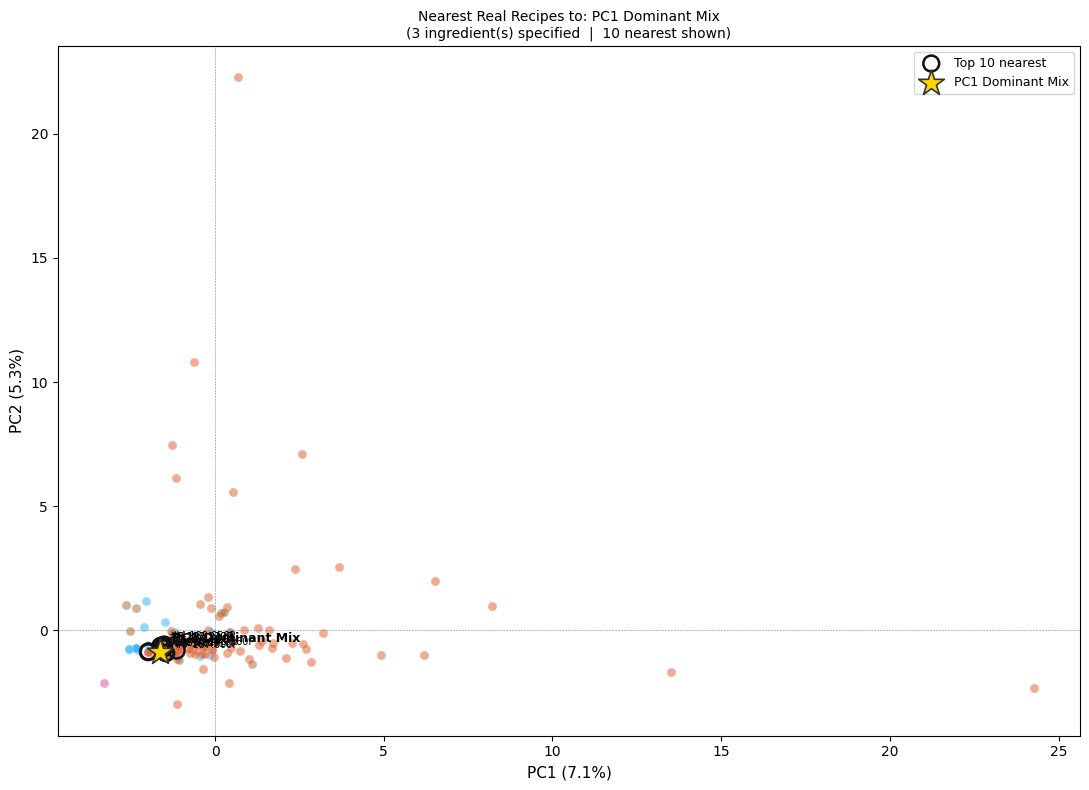

Saved: pca_v1_nearest_PC1_Dominant_Mix.png


In [26]:
# ── Demo 1: auto-build virtual recipe from top PC1 ingredients ──────────────
top3_pc1_idx = np.argsort(np.abs(loadings[0]))[::-1][:3]
top3_pc1_cas = [cas_labels[i] for i in top3_pc1_idx]

# Use median Totalmenge of recipes that actually contain each ingredient
pc1_mix = {}
for cas in top3_pc1_cas:
    if cas not in cas_thresh.index:
        continue
    thresh = float(cas_thresh[cas])
    oavs   = pivot_oav.loc[pivot_oav[cas] > 0, cas]
    if len(oavs) == 0:
        continue
    pc1_mix[cas] = float(oavs.median()) * thresh   # back-convert OAV → Totalmenge

print('Demo virtual recipe (top-3 PC1 ingredients at median concentration):')
for cas, amt in pc1_mix.items():
    print(f'  {cas}  {cas_name.get(cas,"?").split(",")[0][:40]}  amt={amt:.5g}')
print()
_ = nearest_recipes(pc1_mix, n=10, label='PC1 Dominant Mix')

  Furaneol + Vanillin + Linalool  –  resolved 3 ingredient(s):
    3658-77-3        Furaneol Halal                       amt=0.002  OAV=0.0200
    121-33-5         Vanillin ex Eugenol                  amt=0.001  OAV=0.0010
    1365-19-1        Linalooloxid                         amt=0.0005  OAV=0.0005

  Virtual recipe in PCA space: PC1=-0.370  PC2=+2.481  PC3=+6.650

  10 nearest real recipes:
    # 1  186.981P      dist=7.450  PC1=+2.38  PC2=+2.48  (fruity)
    # 2  187.886P      dist=8.265  PC1=-0.21  PC2=+0.02  (fruity)
    # 3  188.375P      dist=8.766  PC1=-0.31  PC2=-0.32  (fruity)
    # 4  189.068       dist=9.403  PC1=-0.70  PC2=-0.26  (fresh)
    # 5  188.819       dist=9.490  PC1=-2.34  PC2=-0.71  (fresh)
    # 6  185.044       dist=9.490  PC1=-2.34  PC2=-0.71  (fresh)
    # 7  185.043P      dist=9.491  PC1=-2.34  PC2=-0.71  (fresh)
    # 8  187.787P      dist=9.672  PC1=+0.46  PC2=-0.08  (fruity)
    # 9  187.521P      dist=9.811  PC1=-1.03  PC2=-0.85  (fruity)
    #10  18

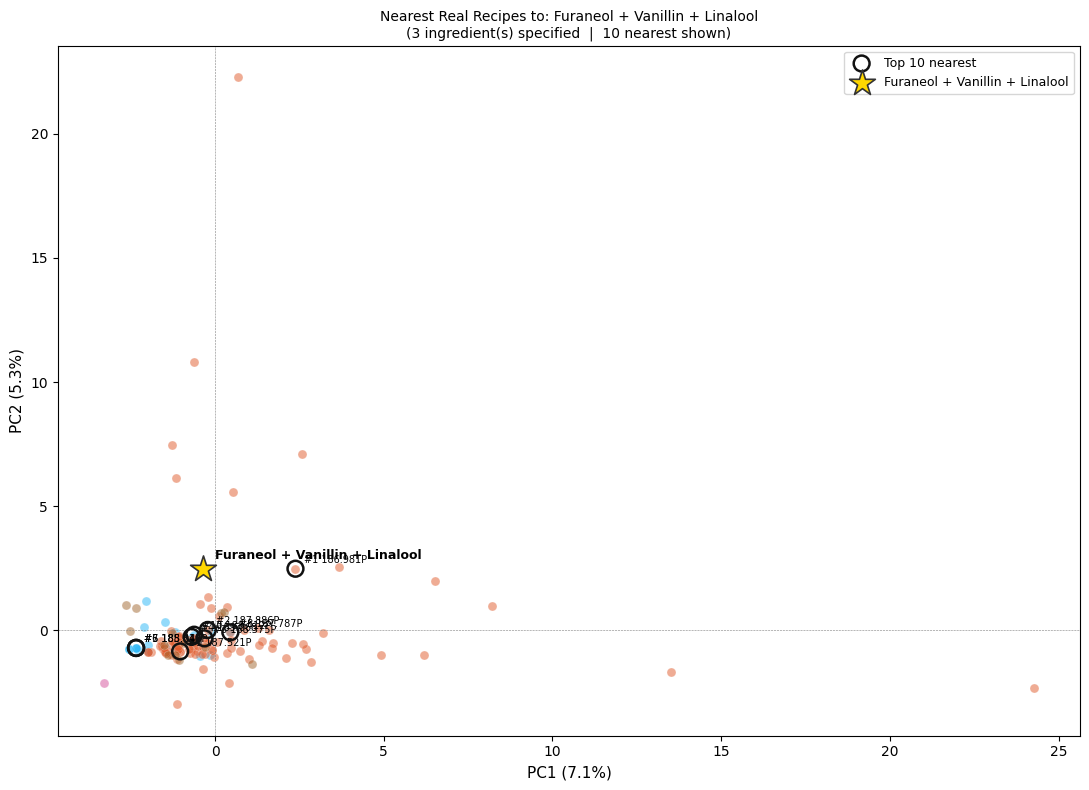

Saved: pca_v1_nearest_Furaneol_x_Vanillin_x_Lin.png


In [27]:
# ── Demo 2: freely-defined mix (edit to explore) ────────────────────────────
# Keys can be partial ingredient names (case-insensitive) or exact CAS numbers.
# Values are Totalmenge in the same unit as the source column.
my_mix = {
    'furaneol':  0.002,    # key strawberry character odorant
    'vanillin':  0.001,    # warm vanilla support
    'linalool':  0.0005,   # floral/fresh lift
}
_ = nearest_recipes(my_mix, n=10, label='Furaneol + Vanillin + Linalool')

---
## 11 · Full Contribution Heatmap + Attribution Export

A complete view of which ingredients drive which recipes across PC1 and PC2,
plus a CSV export with the top-5 ingredient drivers per PC for every recipe.

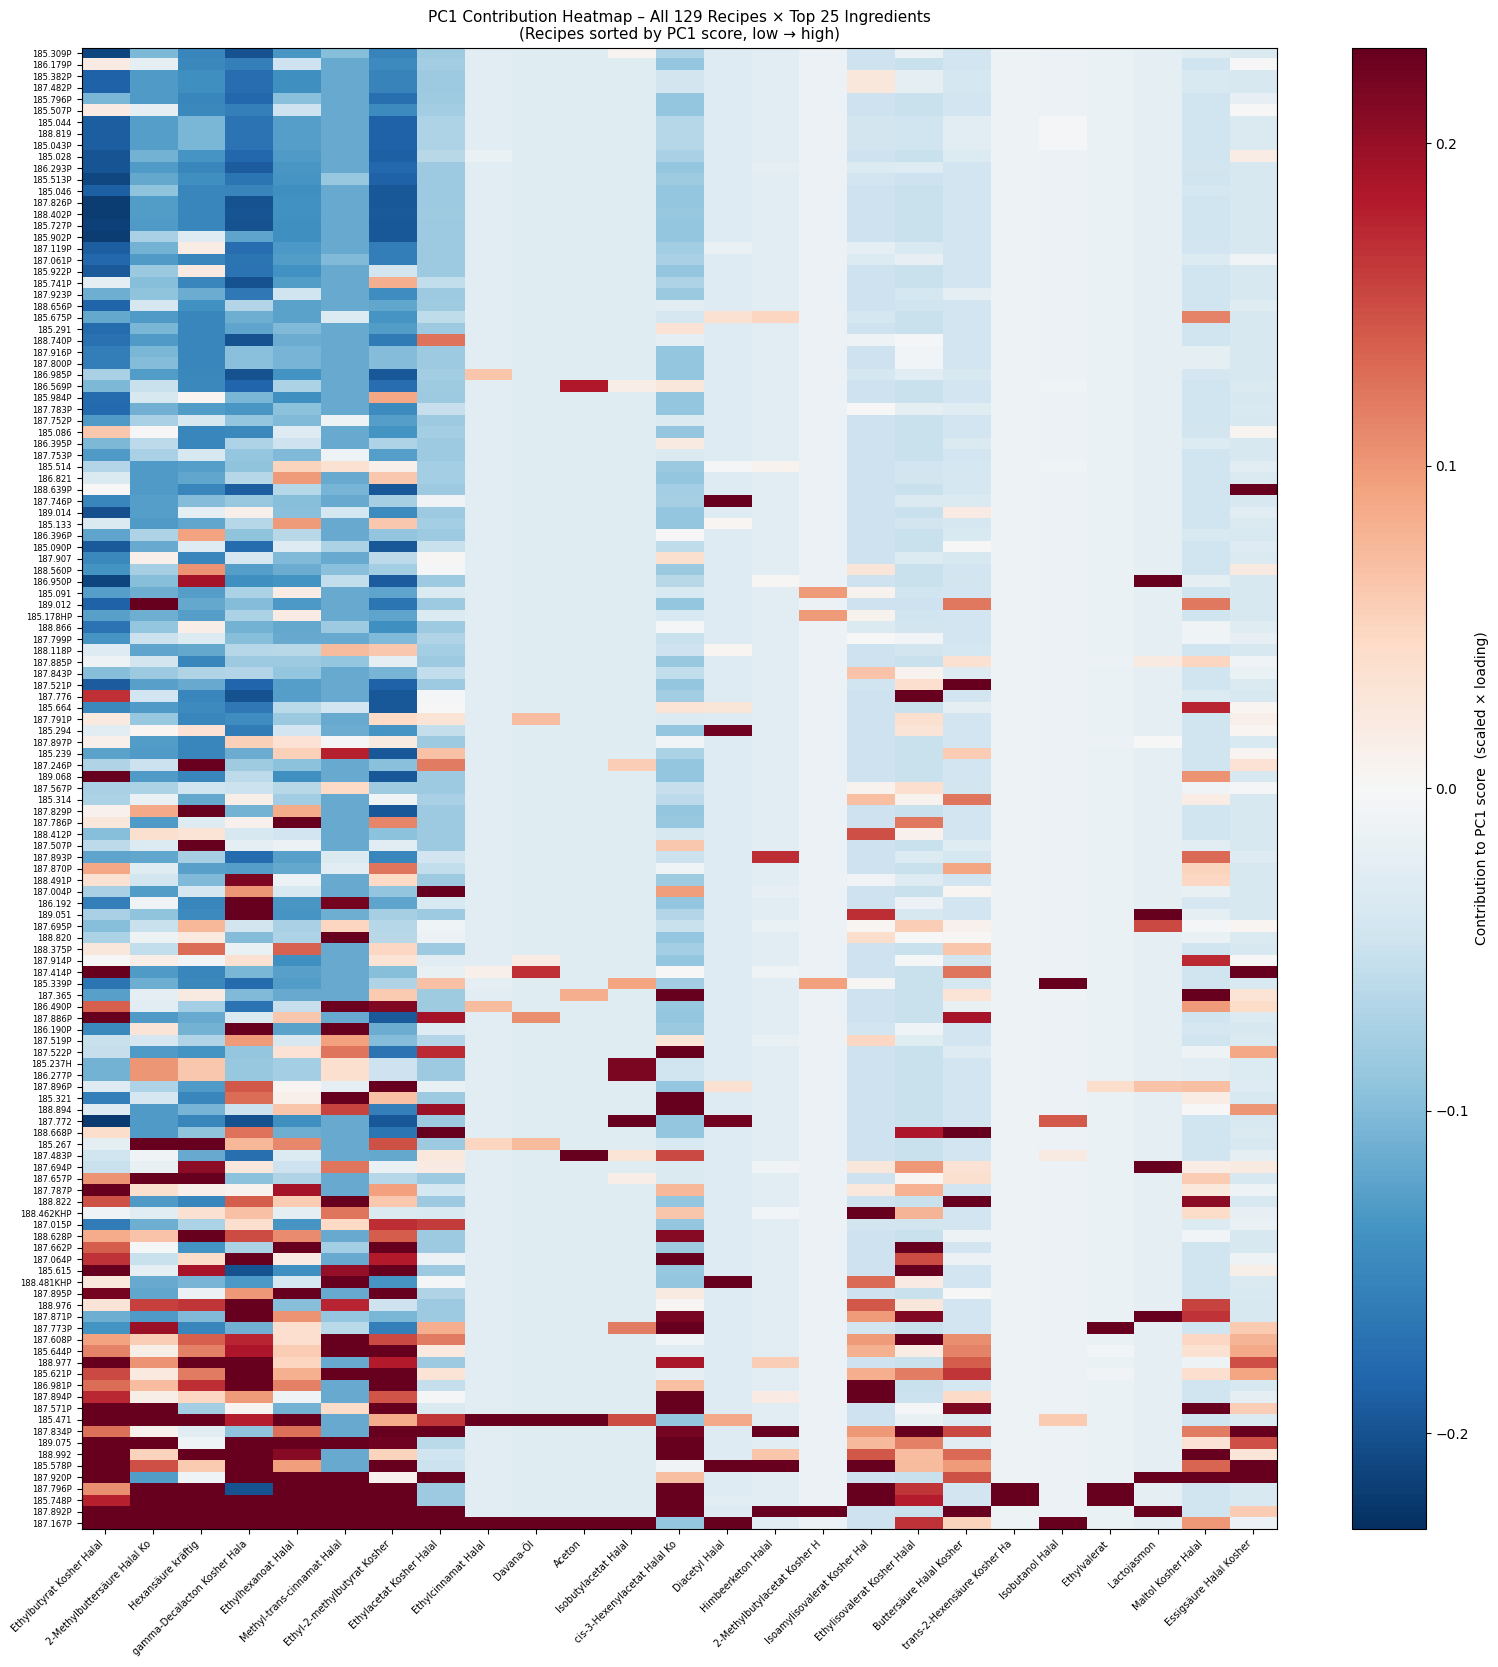

Saved: pca_v1_contrib_heatmap_pc1.png


In [28]:
# ── PC1 contribution heatmap – all recipes × top-25 ingredients ─────────────
N_ING_HEAT = 25

top25_idx  = np.argsort(np.abs(loadings[0]))[::-1][:N_ING_HEAT]
top25_cas  = [cas_labels[i] for i in top25_idx]
top25_lbl  = [cas_name.get(c, c).split(',')[0][:28] for c in top25_cas]

# Contribution of each ingredient to each recipe's PC1 score: (n_recipes, 25)
contrib_pc1 = contrib[:, 0, :][:, top25_idx]

# Sort recipes by PC1 score (low to high) for readability
order = np.argsort(scores_oav[:, 0])
contrib_sorted = contrib_pc1[order]
recipe_labels_sorted = [recipes_oav[i] for i in order]

fig, ax = plt.subplots(figsize=(16, max(8, len(recipes_oav) * 0.13)))
vmax = np.percentile(np.abs(contrib_sorted), 95)
im = ax.imshow(
    contrib_sorted, aspect='auto', cmap='RdBu_r',
    vmin=-vmax, vmax=vmax, interpolation='nearest'
)
ax.set_xticks(range(N_ING_HEAT))
ax.set_xticklabels(top25_lbl, rotation=45, ha='right', fontsize=7)
ax.set_yticks(range(len(recipes_oav)))
ax.set_yticklabels(recipe_labels_sorted, fontsize=6)
plt.colorbar(im, ax=ax, label='Contribution to PC1 score  (scaled × loading)')
ax.set_title(
    f'PC1 Contribution Heatmap – All {len(recipes_oav)} Recipes × Top {N_ING_HEAT} Ingredients\n'
    '(Recipes sorted by PC1 score, low → high)',
    fontsize=11
)
plt.tight_layout()
fig.savefig(OUT_DIR / 'pca_v1_contrib_heatmap_pc1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pca_v1_contrib_heatmap_pc1.png')

In [29]:
# ── Export: per-recipe top-5 ingredient driver per PC → CSV ─────────────────
export_rows = []
for r_idx, rez in enumerate(recipes_oav):
    row = {'Rez.-Nr.': rez, 'Dom_OT': dom_ot_labels[r_idx]}
    for k in range(N_PC_ATTR):
        c_vec = contrib[r_idx, k]
        top5  = np.argsort(np.abs(c_vec))[::-1][:5]
        row[f'PC{k+1}_score'] = round(scores_oav[r_idx, k], 4)
        for rank, i in enumerate(top5, 1):
            cas  = cas_labels[i]
            name = cas_name.get(cas, cas).split(',')[0][:35]
            row[f'PC{k+1}_top{rank}_cas']     = cas
            row[f'PC{k+1}_top{rank}_name']    = name
            row[f'PC{k+1}_top{rank}_contrib']  = round(float(c_vec[i]), 5)
    export_rows.append(row)

attr_df = pd.DataFrame(export_rows).set_index('Rez.-Nr.')
attr_df.to_csv(OUT_DIR / 'pca_v1_recipe_attribution.csv')
print('Exported: pca_v1_recipe_attribution.csv')
print(f'Shape: {attr_df.shape}  ({len(export_rows)} recipes × {attr_df.shape[1]} columns)')
print()
print('Preview (first 4 recipes, first 12 columns):')
print(attr_df.iloc[:4, :12].to_string())

Exported: pca_v1_recipe_attribution.csv
Shape: (129, 65)  (129 recipes × 65 columns)

Preview (first 4 recipes, first 12 columns):
         Dom_OT  PC1_score PC1_top1_cas     PC1_top1_name  PC1_top1_contrib PC1_top2_cas                       PC1_top2_name  PC1_top2_contrib PC1_top3_cas              PC1_top3_name  PC1_top3_contrib PC1_top4_cas
Rez.-Nr.                                                                                                                                                                                                             
185.028   fresh    -2.2800   23696-85-7   beta-Damascenon          -0.24543     105-54-4           Ethylbutyrat Kosher Halal          -0.19878    3025-30-7                Ethyl-trans          -0.19878    7452-79-1
185.043P  fresh    -2.3395    3025-30-7       Ethyl-trans          -0.26368      79-31-2                      Isobuttersäure          -0.26166     105-54-4  Ethylbutyrat Kosher Halal          -0.18890    7452-79-1
185.044   fre

---
## 12 · Key Findings

### 1 — The portfolio has no single dominant axis: variation is spread across many dimensions

The OAV fingerprint PCA shows a very flat scree curve (PC1 = 7.1%, PC2 = 5.3%, PC3 = 4.6%, …).
Ten components together explain only 42% of total variance.
This means **no single "strawberry archetype" exists** — the 129 recipes vary along many independent
axes simultaneously. That is a sign of genuine creative diversity in the portfolio: recipes are not
copies of a master formula with minor tweaks.

By contrast, the **odour-type PCA condenses to 63% in just 2 components** (PC1 = 48.3%, PC2 = 14.7%).
The high-level sensory family of a recipe is therefore much more predictable from its OAV composition
than the exact ingredient identity.

---

### 2 — Four interpretable ingredient axes drive the space

| PC | Var. | Axis character | Key ingredients |
|---|---|---|---|
| **PC1** | 7.1% | **Fruity-ester / fatty-acid richness** | Ethylbutyrat (105-54-4), 2-Methylbuttersäure (116-53-0), Hexansäure (142-62-1), γ-Decalacton (706-14-9), Ethylhexanoat (123-66-0) |
| **PC2** | 5.3% | **Floral / terpene complexity** | Nerolidol (7212-44-4), Methylheptenon (110-93-0), β-Ionon (14901-07-6), Hexylbutyrat (2639-63-6) |
| **PC3** | 4.6% | **Exotic / citrus-floral** | Methylanthranilat (134-20-3), Neroli oil (8016-38-4), Ethyllaurat (106-33-2), Ethylpyruvat (617-35-6) |
| **PC4** | 4.0% | **Spicy-aromatic / rose** | Eugenol (97-53-0), Phenylacetaldehyd (122-78-1), Benzylbenzoat (120-51-4), Phenethylalkohol (60-12-8) |

PC1 and PC2 are **independent** (orthogonal by design) — meaning a recipe can be simultaneously
ester-rich *and* terpene-complex, or neither. The four axes together define a 4D flavour map.

---

### 3 — 74% of recipes are fruity-dominant; three minority clusters exist

| Dominant odour type | Recipes | Mean PC1 |
|---|---|---|
| **fruity** | 95 (74%) | +0.48 |
| **fresh** | 20 (15%) | −1.45 |
| **warm** | 13 (10%) | −1.05 |
| **floral** | 1 (< 1%) | −3.29 |

Fruity-dominant recipes sit consistently at the **positive end of PC1** — they carry more of the core
ester/fatty-acid backbone. Fresh and warm recipes drift toward negative PC1, indicating they use
those ester/fatty blocks less and instead lean on green or thermic notes.
The single floral recipe (185.309P) is the clearest outlier in the portfolio: lowest PC1 score
by a wide margin, unique profile.

---

### 4 — Six near-universal ingredients form the backbone

These ingredients appear in ≥ 100 of 129 recipes and also show the highest mean OAV:

| CAS | Name | Recipes | Mean OAV |
|---|---|---|---|
| 105-54-4 | Ethylbutyrat | **128 / 129** | 0.157 |
| 706-14-9 | γ-Decalacton | 120 / 129 | — |
| 123-66-0 | Ethylhexanoat | 119 / 129 | 0.069 |
| 7452-79-1 | Ethyl-2-methylbutyrat | 118 / 129 | 0.070 |
| 928-96-1 | cis-3-Hexen-1-ol | 116 / 129 | 0.101 |
| 3658-77-3 | Furaneol | 103 / 129 | 0.116 |

**Ethylbutyrat** is essentially mandatory (99% of recipes) and also carries the highest mean OAV —
it is both the most common and the most perceptually impactful ingredient in the set.
**Furaneol**, the iconic caramel-strawberry character odorant, appears in 80% of recipes at a
mean OAV of 0.116, confirming its role as a structural pillar despite being used in small amounts.

---

### 5 — High-impact but selective ingredients: differentiation layer

| CAS | Name | Recipes | Mean OAV |
|---|---|---|---|
| 2432-51-1 | S-(Methylthio)butyrat | selective | **0.129** |
| 123-92-2 | Isoamylacetat | selective | 0.091 |
| 103-26-4 | Methyl-trans-cinnamat | selective | 0.061 |

**S-(Methylthio)butyrat** has a mean OAV of 0.129 — second highest in the set — despite not being
a backbone ingredient. Recipes that include it receive a strong sulfurous-strawberry character boost.
It is a prime candidate for *targeted addition* when you want to differentiate a recipe in PC1.

---

### 6 — Three outlier recipes anchor the extremes

| Recipe | PC | Score | Character |
|---|---|---|---|
| **187.167P** | PC1 | +24.3 | Extreme ester/fatty-acid load — the most "classically fruity" recipe |
| **188.628P** | PC2 | +22.3 | Extreme terpene/floral complexity — the most "floral-terpenic" recipe |
| **187.167P** | PC3 | −9.2 | Also the lowest on PC3 — strongly *anti*-exotic/citrus |
| **185.309P** | PC1 | −3.3 | The lone floral-dominant recipe — structurally distinct from the whole portfolio |

These four recipes are natural **reference standards** for the four ingredient axes.

---

### 7 — Recipe complexity ranges from minimalist to orchestral

- **8 recipes** use ≤ 10 ingredients with OAV data → focused, minimalist compositions
- **26 recipes** use ≥ 30 ingredients with OAV data → complex, multi-note constructions
- **Average**: ~22 OAV-active ingredients per recipe

Minimalist recipes (≤10) are not automatically simpler perceptually — a few ingredients at high OAV
can dominate just as strongly as 30 at low OAV. But they will cluster differently in PCA space
because the scaler amplifies weak signals: these recipes appear "extreme" on components where
their one strong ingredient has a large loading.

---

### 8 — Practical implications

| Question | Answer from PCA |
|---|---|
| "Which existing recipe is closest to my concept?" | Use `nearest_recipes({ingredient: amount})` |
| "What makes recipe X different from recipe Y?" | Compare `explain_recipe(X)` vs `explain_recipe(Y)` — look for sign differences on PC1/PC2 |
| "Which recipes use Furaneol heavily?" | `find_by_ingredient("furaneol")` — top recipes, ranked by OAV |
| "I want to move a recipe toward more terpene complexity" | Increase PC2-positive ingredients: Nerolidol, β-Ionon, Methylheptenon |
| "I want a recipe that reads warmer / less fresh" | Move positive on PC4 (Eugenol, Phenethylalkohol) and negative on PC2 |

## Summary

| | Value |
|---|---|
| Recipes analysed | 129 |
| Ingredients with OAV | 130 CAS |
| PC1 explained variance | — |
| PC2 explained variance | — |
| PC1+PC2 cumulative | — |

**Key observations (fill in after running):**
- Which odour types cluster together?
- Which ingredients drive PC1 vs PC2?
- Are there outlier recipes?

**Output files:**
- `outputs/pca_v1_scree_oav.png`
- `outputs/pca_v1_pc1pc2_oav.png`
- `outputs/pca_v1_biplot_oav.png`
- `outputs/pca_v1_odourtype_biplot.png`
- `outputs/pca_v1_dashboard_pc123.png`
- `outputs/pca_v1_loading_heatmap.png`
- `outputs/pca_v1_scores.csv`